In [1]:
# ============================================================================
# BLOCK 1: DATA LOADING & STATISTICS
# ============================================================================

import numpy as np
import pandas as pd
import os

# Define paths (Mac local)
base_path = os.path.expanduser('~/data/data')
bp_dir = os.path.join(base_path, 'train/BP')
sz_dir = os.path.join(base_path, 'train/SZ')
test_dir = os.path.join(base_path, 'test')

# Load BP subjects
X_bp = []
bp_subjects = []

bp_folders = sorted([d for d in os.listdir(bp_dir) if d.startswith('sub')])
for subj in bp_folders:
    fnc_file = os.path.join(bp_dir, subj, 'fnc.npy')
    if os.path.exists(fnc_file):
        fnc = np.load(fnc_file).squeeze()
        X_bp.append(fnc)
        bp_subjects.append(subj)

# Load SZ subjects
X_sz = []
sz_subjects = []

sz_folders = sorted([d for d in os.listdir(sz_dir) if d.startswith('sub')])
for subj in sz_folders:
    fnc_file = os.path.join(sz_dir, subj, 'fnc.npy')
    if os.path.exists(fnc_file):
        fnc = np.load(fnc_file).squeeze()
        X_sz.append(fnc)
        sz_subjects.append(subj)

# Load test subjects
test_subjects = sorted([d for d in os.listdir(test_dir) if d.startswith('sub')])

# Combine training data
X_static = np.vstack([X_bp, X_sz])
y_labels = np.array([0] * len(X_bp) + [1] * len(X_sz))

# Statistics
print("="*70)
print("DATASET STATISTICS")
print("="*70)

stats_df = pd.DataFrame({
    'Category': ['Bipolar Disorder (BP)', 'Schizophrenia (SZ)', 'Total Training', 
                 'Test Set (unlabeled)', 'Feature Dimensions'],
    'Count': [len(X_bp), len(X_sz), len(X_static), len(test_subjects), 
              f"{X_static.shape[1]} (static FNC)"]
})
print(stats_df.to_string(index=False))
print("="*70)

print(f"\nTraining data shape: {X_static.shape}")
print(f"Labels shape: {y_labels.shape}")
print(f"Class balance: {len(X_bp)}/{len(X_sz)} = {len(X_bp)/len(X_sz):.3f}")
print(f"Majority class baseline: {max(len(X_bp), len(X_sz))/len(X_static)*100:.2f}%")

# Save
np.save('X_static.npy', X_static)
np.save('y_labels.npy', y_labels)

print(f"\n✓ Data loaded successfully")

DATASET STATISTICS
             Category             Count
Bipolar Disorder (BP)               183
   Schizophrenia (SZ)               288
       Total Training               471
 Test Set (unlabeled)               315
   Feature Dimensions 5460 (static FNC)

Training data shape: (471, 5460)
Labels shape: (471,)
Class balance: 183/288 = 0.635
Majority class baseline: 61.15%

✓ Data loaded successfully


In [2]:
# ============================================================================
# BLOCK 2A: LINEAR SVM WITH ALL 5460 FEATURES
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score
import time

# Load data
X_static = np.load('X_static.npy')
y_labels = np.load('y_labels.npy')

print("="*70)
print("BLOCK 2A: LINEAR SVM WITH ALL FEATURES")
print("="*70)

# Initialize CV
np.random.seed(42)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Test
start_time = time.time()
fold_acc = []
fold_auc = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_static, y_labels)):
    X_train, X_val = X_static[train_idx], X_static[val_idx]
    y_train, y_val = y_labels[train_idx], y_labels[val_idx]
    
    model = LinearSVC(class_weight='balanced', max_iter=5000, 
                      random_state=42, dual=False)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    y_score = model.decision_function(X_val)
    
    acc = accuracy_score(y_val, y_pred) * 100
    auc = roc_auc_score(y_val, y_score)
    
    fold_acc.append(acc)
    fold_auc.append(auc)
    
    print(f"  Fold {fold+1:2d}: {acc:.2f}%, AUC: {auc:.4f}")

mean_acc = np.mean(fold_acc)
std_acc = np.std(fold_acc)
mean_auc = np.mean(fold_auc)

print(f"\n{'='*70}")
print(f"Linear SVM (ALL 5460): {mean_acc:.2f}% ± {std_acc:.2f}%, AUC: {mean_auc:.4f}")
print(f"Runtime: {time.time() - start_time:.1f}s")
print(f"{'='*70}")

# Save
result_2a = {
    'Model': 'Linear SVM',
    'Method': 'ALL',
    'Features': 5460,
    'Accuracy': mean_acc,
    'Std': std_acc,
    'AUC': mean_auc
}
np.save('result_2a.npy', result_2a, allow_pickle=True)
print("\n✓ Block 2A complete")

BLOCK 2A: LINEAR SVM WITH ALL FEATURES
  Fold  1: 62.50%, AUC: 0.6806
  Fold  2: 63.83%, AUC: 0.6823
  Fold  3: 51.06%, AUC: 0.5150
  Fold  4: 61.70%, AUC: 0.6418
  Fold  5: 65.96%, AUC: 0.6782
  Fold  6: 68.09%, AUC: 0.7414
  Fold  7: 63.83%, AUC: 0.5843
  Fold  8: 63.83%, AUC: 0.5690
  Fold  9: 72.34%, AUC: 0.7146
  Fold 10: 51.06%, AUC: 0.5249

Linear SVM (ALL 5460): 62.42% ± 6.38%, AUC: 0.6332
Runtime: 48.8s

✓ Block 2A complete


In [3]:
# ============================================================================
# BLOCK 2B: RBF SVM WITH ALL FEATURES (STANDARDIZED)
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.preprocessing import StandardScaler
import time

# Load data
X_static = np.load('X_static.npy')
y_labels = np.load('y_labels.npy')

print("="*70)
print("BLOCK 2B: RBF SVM WITH ALL FEATURES")
print("="*70)

# Initialize CV
np.random.seed(42)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Test
start_time = time.time()
fold_acc = []
fold_auc = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_static, y_labels)):
    X_train, X_val = X_static[train_idx], X_static[val_idx]
    y_train, y_val = y_labels[train_idx], y_labels[val_idx]
    
    # Standardize (critical for RBF)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    model = SVC(kernel='rbf', C=1, gamma='scale', class_weight='balanced',
                probability=True, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_val_scaled)
    y_proba = model.predict_proba(X_val_scaled)[:, 1]
    
    acc = accuracy_score(y_val, y_pred) * 100
    auc = roc_auc_score(y_val, y_proba)
    
    fold_acc.append(acc)
    fold_auc.append(auc)
    
    print(f"  Fold {fold+1:2d}: {acc:.2f}%, AUC: {auc:.4f}")

mean_acc = np.mean(fold_acc)
std_acc = np.std(fold_acc)
mean_auc = np.mean(fold_auc)

print(f"\n{'='*70}")
print(f"RBF SVM (ALL 5460): {mean_acc:.2f}% ± {std_acc:.2f}%, AUC: {mean_auc:.4f}")
print(f"Runtime: {time.time() - start_time:.1f}s")
print(f"{'='*70}")

# Save
result_2b = {
    'Model': 'RBF SVM',
    'Method': 'ALL',
    'Features': 5460,
    'Accuracy': mean_acc,
    'Std': std_acc,
    'AUC': mean_auc
}
np.save('result_2b.npy', result_2b, allow_pickle=True)
print("\n✓ Block 2B complete")

BLOCK 2B: RBF SVM WITH ALL FEATURES
  Fold  1: 60.42%, AUC: 0.6425
  Fold  2: 65.96%, AUC: 0.7124
  Fold  3: 61.70%, AUC: 0.6147
  Fold  4: 63.83%, AUC: 0.6111
  Fold  5: 65.96%, AUC: 0.7050
  Fold  6: 59.57%, AUC: 0.6437
  Fold  7: 63.83%, AUC: 0.6705
  Fold  8: 68.09%, AUC: 0.7031
  Fold  9: 65.96%, AUC: 0.6858
  Fold 10: 57.45%, AUC: 0.5747

RBF SVM (ALL 5460): 63.28% ± 3.22%, AUC: 0.6563
Runtime: 7.2s

✓ Block 2B complete


In [4]:
# ============================================================================
# BLOCK 2C: RANDOM FOREST WITH ALL FEATURES
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score
import time

# Load data
X_static = np.load('X_static.npy')
y_labels = np.load('y_labels.npy')

print("="*70)
print("BLOCK 2C: RANDOM FOREST WITH ALL FEATURES")
print("="*70)

# Initialize CV
np.random.seed(42)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Test
start_time = time.time()
fold_acc = []
fold_auc = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_static, y_labels)):
    X_train, X_val = X_static[train_idx], X_static[val_idx]
    y_train, y_val = y_labels[train_idx], y_labels[val_idx]
    
    model = RandomForestClassifier(
        n_estimators=500,
        max_depth=20,
        min_samples_split=5,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]
    
    acc = accuracy_score(y_val, y_pred) * 100
    auc = roc_auc_score(y_val, y_proba)
    
    fold_acc.append(acc)
    fold_auc.append(auc)
    
    print(f"  Fold {fold+1:2d}: {acc:.2f}%, AUC: {auc:.4f}")

mean_acc = np.mean(fold_acc)
std_acc = np.std(fold_acc)
mean_auc = np.mean(fold_auc)

print(f"\n{'='*70}")
print(f"Random Forest (ALL 5460): {mean_acc:.2f}% ± {std_acc:.2f}%, AUC: {mean_auc:.4f}")
print(f"Runtime: {time.time() - start_time:.1f}s")
print(f"{'='*70}")

# Save
result_2c = {
    'Model': 'Random Forest',
    'Method': 'ALL',
    'Features': 5460,
    'Accuracy': mean_acc,
    'Std': std_acc,
    'AUC': mean_auc
}
np.save('result_2c.npy', result_2c, allow_pickle=True)
print("\n✓ Block 2C complete")

BLOCK 2C: RANDOM FOREST WITH ALL FEATURES
  Fold  1: 56.25%, AUC: 0.6352
  Fold  2: 61.70%, AUC: 0.7237
  Fold  3: 59.57%, AUC: 0.6184
  Fold  4: 63.83%, AUC: 0.5632
  Fold  5: 63.83%, AUC: 0.6705
  Fold  6: 63.83%, AUC: 0.6092
  Fold  7: 65.96%, AUC: 0.6705
  Fold  8: 63.83%, AUC: 0.6226
  Fold  9: 65.96%, AUC: 0.6034
  Fold 10: 65.96%, AUC: 0.5402

Random Forest (ALL 5460): 63.07% ± 2.97%, AUC: 0.6257
Runtime: 6.4s

✓ Block 2C complete


In [7]:
# ============================================================================
# BLOCK 2E1: LINEAR SVM WITH MI-DISR 100 FEATURES
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.feature_selection import mutual_info_classif
import time

# Load data
X_static = np.load('X_static.npy')
y_labels = np.load('y_labels.npy')

print("="*70)
print("BLOCK 2E1: LINEAR SVM WITH MI-DISR 100 FEATURES")
print("="*70)

# MI-DISR function
def select_features_mi_disr(X_train, y_train, n_features, beta=1.0):
    mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
    top_candidates = np.argsort(mi_scores)[-min(1000, len(mi_scores)):]
    X_candidates = X_train[:, top_candidates]
    
    selected = []
    remaining = list(range(len(top_candidates)))
    first_idx = np.argmax(mi_scores[top_candidates])
    selected.append(first_idx)
    remaining.remove(first_idx)
    
    for _ in range(min(n_features - 1, len(remaining))):
        best_score = -np.inf
        best_idx = None
        
        for idx in remaining:
            redundancy = 0
            for sel_idx in selected:
                corr = np.corrcoef(X_candidates[:, idx], X_candidates[:, sel_idx])[0, 1]
                redundancy += abs(corr)
            if len(selected) > 0:
                redundancy /= len(selected)
            
            score = mi_scores[top_candidates[idx]] - beta * redundancy
            if score > best_score:
                best_score = score
                best_idx = idx
        
        if best_idx is not None:
            selected.append(best_idx)
            remaining.remove(best_idx)
    
    return top_candidates[selected]

# CV
np.random.seed(42)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

start_time = time.time()
fold_acc = []
fold_auc = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_static, y_labels)):
    X_train, X_val = X_static[train_idx], X_static[val_idx]
    y_train, y_val = y_labels[train_idx], y_labels[val_idx]
    
    selected_indices = select_features_mi_disr(X_train, y_train, 100)
    X_train_selected = X_train[:, selected_indices]
    X_val_selected = X_val[:, selected_indices]
    
    model = LinearSVC(class_weight='balanced', max_iter=5000, random_state=42, dual=False)
    model.fit(X_train_selected, y_train)
    
    y_pred = model.predict(X_val_selected)
    y_score = model.decision_function(X_val_selected)
    
    acc = accuracy_score(y_val, y_pred) * 100
    auc = roc_auc_score(y_val, y_score)
    
    fold_acc.append(acc)
    fold_auc.append(auc)
    print(f"  Fold {fold+1:2d}: {acc:.2f}%, AUC: {auc:.4f}")

mean_acc = np.mean(fold_acc)
std_acc = np.std(fold_acc)
mean_auc = np.mean(fold_auc)

print(f"\n{'='*70}")
print(f"Linear SVM + MI-DISR 100: {mean_acc:.2f}% ± {std_acc:.2f}%, AUC: {mean_auc:.4f}")
print(f"Runtime: {time.time() - start_time:.1f}s")
print(f"{'='*70}")

result_2e1 = {
    'Model': 'Linear SVM',
    'Method': 'MI-DISR',
    'Features': 100,
    'Accuracy': mean_acc,
    'Std': std_acc,
    'AUC': mean_auc
}
np.save('result_2e1.npy', result_2e1, allow_pickle=True)
print("\n✓ Block 2E1 complete")

BLOCK 2E1: LINEAR SVM WITH MI-DISR 100 FEATURES
  Fold  1: 58.33%, AUC: 0.5844
  Fold  2: 46.81%, AUC: 0.5733
  Fold  3: 46.81%, AUC: 0.4793
  Fold  4: 59.57%, AUC: 0.5651
  Fold  5: 51.06%, AUC: 0.6284
  Fold  6: 61.70%, AUC: 0.6322
  Fold  7: 65.96%, AUC: 0.6743
  Fold  8: 44.68%, AUC: 0.4023
  Fold  9: 63.83%, AUC: 0.6437
  Fold 10: 63.83%, AUC: 0.6284

Linear SVM + MI-DISR 100: 56.26% ± 7.70%, AUC: 0.5811
Runtime: 642.0s

✓ Block 2E1 complete


In [8]:
# ============================================================================
# BLOCK 2E2: LINEAR SVM WITH MI-DISR 200 FEATURES
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.feature_selection import mutual_info_classif
import time

X_static = np.load('X_static.npy')
y_labels = np.load('y_labels.npy')

print("="*70)
print("BLOCK 2E2: LINEAR SVM WITH MI-DISR 200 FEATURES")
print("="*70)

def select_features_mi_disr(X_train, y_train, n_features, beta=1.0):
    mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
    top_candidates = np.argsort(mi_scores)[-min(1000, len(mi_scores)):]
    X_candidates = X_train[:, top_candidates]
    
    selected = []
    remaining = list(range(len(top_candidates)))
    first_idx = np.argmax(mi_scores[top_candidates])
    selected.append(first_idx)
    remaining.remove(first_idx)
    
    for _ in range(min(n_features - 1, len(remaining))):
        best_score = -np.inf
        best_idx = None
        
        for idx in remaining:
            redundancy = 0
            for sel_idx in selected:
                corr = np.corrcoef(X_candidates[:, idx], X_candidates[:, sel_idx])[0, 1]
                redundancy += abs(corr)
            if len(selected) > 0:
                redundancy /= len(selected)
            
            score = mi_scores[top_candidates[idx]] - beta * redundancy
            if score > best_score:
                best_score = score
                best_idx = idx
        
        if best_idx is not None:
            selected.append(best_idx)
            remaining.remove(best_idx)
    
    return top_candidates[selected]

np.random.seed(42)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

start_time = time.time()
fold_acc = []
fold_auc = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_static, y_labels)):
    X_train, X_val = X_static[train_idx], X_static[val_idx]
    y_train, y_val = y_labels[train_idx], y_labels[val_idx]
    
    selected_indices = select_features_mi_disr(X_train, y_train, 200)
    X_train_selected = X_train[:, selected_indices]
    X_val_selected = X_val[:, selected_indices]
    
    model = LinearSVC(class_weight='balanced', max_iter=5000, random_state=42, dual=False)
    model.fit(X_train_selected, y_train)
    
    y_pred = model.predict(X_val_selected)
    y_score = model.decision_function(X_val_selected)
    
    acc = accuracy_score(y_val, y_pred) * 100
    auc = roc_auc_score(y_val, y_score)
    
    fold_acc.append(acc)
    fold_auc.append(auc)
    print(f"  Fold {fold+1:2d}: {acc:.2f}%, AUC: {auc:.4f}")

mean_acc = np.mean(fold_acc)
std_acc = np.std(fold_acc)
mean_auc = np.mean(fold_auc)

print(f"\n{'='*70}")
print(f"Linear SVM + MI-DISR 200: {mean_acc:.2f}% ± {std_acc:.2f}%, AUC: {mean_auc:.4f}")
print(f"Runtime: {time.time() - start_time:.1f}s")
print(f"{'='*70}")

result_2e2 = {
    'Model': 'Linear SVM',
    'Method': 'MI-DISR',
    'Features': 200,
    'Accuracy': mean_acc,
    'Std': std_acc,
    'AUC': mean_auc
}
np.save('result_2e2.npy', result_2e2, allow_pickle=True)
print("\n✓ Block 2E2 complete")

BLOCK 2E2: LINEAR SVM WITH MI-DISR 200 FEATURES
  Fold  1: 58.33%, AUC: 0.5717
  Fold  2: 55.32%, AUC: 0.5808
  Fold  3: 59.57%, AUC: 0.5714
  Fold  4: 63.83%, AUC: 0.5556
  Fold  5: 61.70%, AUC: 0.6322
  Fold  6: 70.21%, AUC: 0.6686
  Fold  7: 61.70%, AUC: 0.6341
  Fold  8: 57.45%, AUC: 0.5613
  Fold  9: 61.70%, AUC: 0.6284
  Fold 10: 59.57%, AUC: 0.5766

Linear SVM + MI-DISR 200: 60.94% ± 3.88%, AUC: 0.5981
Runtime: 2187.9s

✓ Block 2E2 complete


In [9]:
# ============================================================================
# BLOCK 2E3: LINEAR SVM WITH MI-DISR 300 FEATURES (OPTIMIZED)
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.feature_selection import mutual_info_classif
import time

X_static = np.load('X_static.npy')
y_labels = np.load('y_labels.npy')

print("="*70)
print("BLOCK 2E3: LINEAR SVM WITH MI-DISR 300 FEATURES (OPTIMIZED)")
print("="*70)

def select_features_mi_disr_optimized(X_train, y_train, n_features, beta=1.0):
    """Optimized MI-DISR with pre-computed correlation matrix"""
    
    # Compute MI scores
    mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
    
    # Work with top 1000 candidates
    top_candidates = np.argsort(mi_scores)[-min(1000, len(mi_scores)):]
    X_candidates = X_train[:, top_candidates]
    mi_candidates = mi_scores[top_candidates]
    
    # Pre-compute correlation matrix (KEY OPTIMIZATION)
    corr_matrix = np.corrcoef(X_candidates.T)
    np.fill_diagonal(corr_matrix, 0)
    corr_matrix = np.abs(corr_matrix)
    
    # Initialize
    selected = []
    remaining = set(range(len(top_candidates)))
    
    # Select first feature (highest MI)
    first_idx = np.argmax(mi_candidates)
    selected.append(first_idx)
    remaining.remove(first_idx)
    
    # Iteratively select remaining features
    for _ in range(min(n_features - 1, len(remaining))):
        best_score = -np.inf
        best_idx = None
        
        for idx in remaining:
            # Mean correlation with already-selected features (vectorized)
            if len(selected) > 0:
                redundancy = corr_matrix[idx, selected].mean()
            else:
                redundancy = 0
            
            # DISR score
            score = mi_candidates[idx] - beta * redundancy
            
            if score > best_score:
                best_score = score
                best_idx = idx
        
        if best_idx is not None:
            selected.append(best_idx)
            remaining.remove(best_idx)
    
    # Convert back to original indices
    selected_features = top_candidates[selected]
    return selected_features

# CV
np.random.seed(42)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

start_time = time.time()
fold_acc = []
fold_auc = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_static, y_labels)):
    fold_start = time.time()
    
    X_train, X_val = X_static[train_idx], X_static[val_idx]
    y_train, y_val = y_labels[train_idx], y_labels[val_idx]
    
    # Feature selection with optimized function
    selected_indices = select_features_mi_disr_optimized(X_train, y_train, 300)
    X_train_selected = X_train[:, selected_indices]
    X_val_selected = X_val[:, selected_indices]
    
    # Train
    model = LinearSVC(class_weight='balanced', max_iter=5000, random_state=42, dual=False)
    model.fit(X_train_selected, y_train)
    
    # Evaluate
    y_pred = model.predict(X_val_selected)
    y_score = model.decision_function(X_val_selected)
    
    acc = accuracy_score(y_val, y_pred) * 100
    auc = roc_auc_score(y_val, y_score)
    
    fold_acc.append(acc)
    fold_auc.append(auc)
    
    fold_time = time.time() - fold_start
    print(f"  Fold {fold+1:2d}: {acc:.2f}%, AUC: {auc:.4f} ({fold_time:.1f}s)")

mean_acc = np.mean(fold_acc)
std_acc = np.std(fold_acc)
mean_auc = np.mean(fold_auc)
total_time = time.time() - start_time

print(f"\n{'='*70}")
print(f"Linear SVM + MI-DISR 300: {mean_acc:.2f}% ± {std_acc:.2f}%, AUC: {mean_auc:.4f}")
print(f"Total runtime: {total_time:.1f}s ({total_time/60:.1f} minutes)")
print(f"{'='*70}")

# Save
result_2e3 = {
    'Model': 'Linear SVM',
    'Method': 'MI-DISR',
    'Features': 300,
    'Accuracy': mean_acc,
    'Std': std_acc,
    'AUC': mean_auc
}
np.save('result_2e3.npy', result_2e3, allow_pickle=True)
print("\n✓ Block 2E3 complete")

BLOCK 2E3: LINEAR SVM WITH MI-DISR 300 FEATURES (OPTIMIZED)
  Fold  1: 60.42%, AUC: 0.6388 (4.2s)
  Fold  2: 61.70%, AUC: 0.6673 (4.2s)
  Fold  3: 65.96%, AUC: 0.6335 (4.2s)
  Fold  4: 59.57%, AUC: 0.5479 (4.2s)
  Fold  5: 57.45%, AUC: 0.5421 (4.1s)
  Fold  6: 68.09%, AUC: 0.7241 (4.2s)
  Fold  7: 57.45%, AUC: 0.5517 (4.1s)
  Fold  8: 51.06%, AUC: 0.5651 (4.1s)
  Fold  9: 65.96%, AUC: 0.6513 (4.1s)
  Fold 10: 53.19%, AUC: 0.5728 (4.1s)

Linear SVM + MI-DISR 300: 60.08% ± 5.28%, AUC: 0.6095
Total runtime: 41.6s (0.7 minutes)

✓ Block 2E3 complete


In [10]:
# ============================================================================
# BLOCK 2E4: LINEAR SVM WITH MI-DISR 400 FEATURES (OPTIMIZED)
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.feature_selection import mutual_info_classif
import time

X_static = np.load('X_static.npy')
y_labels = np.load('y_labels.npy')

print("="*70)
print("BLOCK 2E4: LINEAR SVM WITH MI-DISR 400 FEATURES (OPTIMIZED)")
print("="*70)

def select_features_mi_disr_optimized(X_train, y_train, n_features, beta=1.0):
    """Optimized MI-DISR with pre-computed correlation matrix"""
    
    # Compute MI scores
    mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
    
    # Work with top 1000 candidates
    top_candidates = np.argsort(mi_scores)[-min(1000, len(mi_scores)):]
    X_candidates = X_train[:, top_candidates]
    mi_candidates = mi_scores[top_candidates]
    
    # Pre-compute correlation matrix (KEY OPTIMIZATION)
    corr_matrix = np.corrcoef(X_candidates.T)
    np.fill_diagonal(corr_matrix, 0)
    corr_matrix = np.abs(corr_matrix)
    
    # Initialize
    selected = []
    remaining = set(range(len(top_candidates)))
    
    # Select first feature (highest MI)
    first_idx = np.argmax(mi_candidates)
    selected.append(first_idx)
    remaining.remove(first_idx)
    
    # Iteratively select remaining features
    for _ in range(min(n_features - 1, len(remaining))):
        best_score = -np.inf
        best_idx = None
        
        for idx in remaining:
            # Mean correlation with already-selected features (vectorized)
            if len(selected) > 0:
                redundancy = corr_matrix[idx, selected].mean()
            else:
                redundancy = 0
            
            # DISR score
            score = mi_candidates[idx] - beta * redundancy
            
            if score > best_score:
                best_score = score
                best_idx = idx
        
        if best_idx is not None:
            selected.append(best_idx)
            remaining.remove(best_idx)
    
    # Convert back to original indices
    selected_features = top_candidates[selected]
    return selected_features

# CV
np.random.seed(42)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

start_time = time.time()
fold_acc = []
fold_auc = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_static, y_labels)):
    fold_start = time.time()
    
    X_train, X_val = X_static[train_idx], X_static[val_idx]
    y_train, y_val = y_labels[train_idx], y_labels[val_idx]
    
    # Feature selection with optimized function
    selected_indices = select_features_mi_disr_optimized(X_train, y_train, 400)
    X_train_selected = X_train[:, selected_indices]
    X_val_selected = X_val[:, selected_indices]
    
    # Train
    model = LinearSVC(class_weight='balanced', max_iter=5000, random_state=42, dual=False)
    model.fit(X_train_selected, y_train)
    
    # Evaluate
    y_pred = model.predict(X_val_selected)
    y_score = model.decision_function(X_val_selected)
    
    acc = accuracy_score(y_val, y_pred) * 100
    auc = roc_auc_score(y_val, y_score)
    
    fold_acc.append(acc)
    fold_auc.append(auc)
    
    fold_time = time.time() - fold_start
    print(f"  Fold {fold+1:2d}: {acc:.2f}%, AUC: {auc:.4f} ({fold_time:.1f}s)")

mean_acc = np.mean(fold_acc)
std_acc = np.std(fold_acc)
mean_auc = np.mean(fold_auc)
total_time = time.time() - start_time

print(f"\n{'='*70}")
print(f"Linear SVM + MI-DISR 400: {mean_acc:.2f}% ± {std_acc:.2f}%, AUC: {mean_auc:.4f}")
print(f"Total runtime: {total_time:.1f}s ({total_time/60:.1f} minutes)")
print(f"{'='*70}")

# Save
result_2e4 = {
    'Model': 'Linear SVM',
    'Method': 'MI-DISR',
    'Features': 400,
    'Accuracy': mean_acc,
    'Std': std_acc,
    'AUC': mean_auc
}
np.save('result_2e4.npy', result_2e4, allow_pickle=True)
print("\n✓ Block 2E4 complete")

BLOCK 2E4: LINEAR SVM WITH MI-DISR 400 FEATURES (OPTIMIZED)
  Fold  1: 66.67%, AUC: 0.6515 (4.8s)
  Fold  2: 59.57%, AUC: 0.6429 (4.7s)
  Fold  3: 65.96%, AUC: 0.6391 (4.7s)
  Fold  4: 48.94%, AUC: 0.3870 (4.8s)
  Fold  5: 51.06%, AUC: 0.5996 (4.7s)
  Fold  6: 65.96%, AUC: 0.7931 (4.7s)
  Fold  7: 65.96%, AUC: 0.6111 (4.7s)
  Fold  8: 59.57%, AUC: 0.5900 (4.6s)
  Fold  9: 61.70%, AUC: 0.6015 (4.7s)
  Fold 10: 53.19%, AUC: 0.5670 (4.7s)

Linear SVM + MI-DISR 400: 59.86% ± 6.35%, AUC: 0.6083
Total runtime: 47.1s (0.8 minutes)

✓ Block 2E4 complete


In [11]:
# ============================================================================
# STATISTICAL TEST: LINEAR SVM BASELINE VS FEATURE SELECTION
# ============================================================================

import numpy as np
from scipy import stats

print("="*70)
print("STATISTICAL SIGNIFICANCE TEST: LINEAR SVM")
print("="*70)

# Load results
result_2a = np.load('result_2a.npy', allow_pickle=True).item()
result_2e1 = np.load('result_2e1.npy', allow_pickle=True).item()
result_2e2 = np.load('result_2e2.npy', allow_pickle=True).item()
result_2e3 = np.load('result_2e3.npy', allow_pickle=True).item()
result_2e4 = np.load('result_2e4.npy', allow_pickle=True).item()

baseline_acc = result_2a['Accuracy']

results = [
    ('100 features', result_2e1['Accuracy'], result_2e1['Std']),
    ('200 features', result_2e2['Accuracy'], result_2e2['Std']),
    ('300 features', result_2e3['Accuracy'], result_2e3['Std']),
    ('400 features', result_2e4['Accuracy'], result_2e4['Std'])
]

print(f"\nBaseline (ALL 5460): {baseline_acc:.2f}% ± {result_2a['Std']:.2f}%\n")
print(f"{'Method':<20} {'Accuracy':<15} {'Difference':<15} {'Conclusion'}")
print("-"*70)

for method, acc, std in results:
    diff = acc - baseline_acc
    
    # Rough significance check (assumes normal distribution)
    # Combined std error for independent samples
    se_combined = np.sqrt(result_2a['Std']**2 + std**2) / np.sqrt(10)
    t_stat = diff / se_combined
    
    # Two-tailed test
    if abs(t_stat) < 2.0:  # Rough threshold for p < 0.05 with df~18
        conclusion = "No significant difference"
    elif diff > 0:
        conclusion = "Significantly better"
    else:
        conclusion = "Significantly worse"
    
    print(f"{method:<20} {acc:.2f}%±{std:.2f}% {diff:+6.2f}%        {conclusion}")

print("\n" + "="*70)
print("CONCLUSION:")
print("No feature selection method significantly outperforms baseline.")
print("Feature selection provides no benefit for Linear SVM.")
print("="*70)


STATISTICAL SIGNIFICANCE TEST: LINEAR SVM

Baseline (ALL 5460): 62.42% ± 6.38%

Method               Accuracy        Difference      Conclusion
----------------------------------------------------------------------
100 features         56.26%±7.70%  -6.16%        No significant difference
200 features         60.94%±3.88%  -1.48%        No significant difference
300 features         60.08%±5.28%  -2.34%        No significant difference
400 features         59.86%±6.35%  -2.56%        No significant difference

CONCLUSION:
No feature selection method significantly outperforms baseline.
Feature selection provides no benefit for Linear SVM.


In [12]:
# ============================================================================
# BLOCK 2F: RBF SVM WITH MI-DISR FEATURE SELECTION (ALL COUNTS)
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.feature_selection import mutual_info_classif
import time

X_static = np.load('X_static.npy')
y_labels = np.load('y_labels.npy')

print("="*70)
print("BLOCK 2F: RBF SVM WITH MI-DISR FEATURE SELECTION")
print("="*70)
print("Testing 4 feature counts: 100, 200, 300, 400")
print("Using optimized MI-DISR with standardization\n")

# Optimized MI-DISR function
def select_features_mi_disr_optimized(X_train, y_train, n_features, beta=1.0):
    """Optimized MI-DISR with pre-computed correlation matrix"""
    
    mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
    top_candidates = np.argsort(mi_scores)[-min(1000, len(mi_scores)):]
    X_candidates = X_train[:, top_candidates]
    mi_candidates = mi_scores[top_candidates]
    
    # Pre-compute correlation matrix
    corr_matrix = np.corrcoef(X_candidates.T)
    np.fill_diagonal(corr_matrix, 0)
    corr_matrix = np.abs(corr_matrix)
    
    selected = []
    remaining = set(range(len(top_candidates)))
    
    first_idx = np.argmax(mi_candidates)
    selected.append(first_idx)
    remaining.remove(first_idx)
    
    for _ in range(min(n_features - 1, len(remaining))):
        best_score = -np.inf
        best_idx = None
        
        for idx in remaining:
            if len(selected) > 0:
                redundancy = corr_matrix[idx, selected].mean()
            else:
                redundancy = 0
            
            score = mi_candidates[idx] - beta * redundancy
            
            if score > best_score:
                best_score = score
                best_idx = idx
        
        if best_idx is not None:
            selected.append(best_idx)
            remaining.remove(best_idx)
    
    return top_candidates[selected]

# Initialize CV
np.random.seed(42)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Test feature counts
feature_counts = [100, 200, 300, 400]
all_results = []

# Load baseline
result_2b = np.load('result_2b.npy', allow_pickle=True).item()
all_results.append(result_2b)

print(f"Baseline (ALL 5460): {result_2b['Accuracy']:.2f}% ± {result_2b['Std']:.2f}%\n")

# Test each feature count
for n_features in feature_counts:
    print("="*70)
    print(f"RBF SVM + MI-DISR {n_features} FEATURES")
    print("="*70)
    
    test_start = time.time()
    fold_acc = []
    fold_auc = []
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_static, y_labels)):
        fold_start = time.time()
        
        X_train, X_val = X_static[train_idx], X_static[val_idx]
        y_train, y_val = y_labels[train_idx], y_labels[val_idx]
        
        # Feature selection (nested CV)
        selected_indices = select_features_mi_disr_optimized(X_train, y_train, n_features)
        X_train_selected = X_train[:, selected_indices]
        X_val_selected = X_val[:, selected_indices]
        
        # Standardization (CRITICAL for RBF)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_selected)
        X_val_scaled = scaler.transform(X_val_selected)
        
        # RBF SVM
        model = SVC(kernel='rbf', C=1, gamma='scale', class_weight='balanced',
                    probability=True, random_state=42)
        model.fit(X_train_scaled, y_train)
        
        # Evaluate
        y_pred = model.predict(X_val_scaled)
        y_proba = model.predict_proba(X_val_scaled)[:, 1]
        
        acc = accuracy_score(y_val, y_pred) * 100
        auc = roc_auc_score(y_val, y_proba)
        
        fold_acc.append(acc)
        fold_auc.append(auc)
        
        fold_time = time.time() - fold_start
        print(f"  Fold {fold+1:2d}: {acc:.2f}%, AUC: {auc:.4f} ({fold_time:.1f}s)")
    
    mean_acc = np.mean(fold_acc)
    std_acc = np.std(fold_acc)
    mean_auc = np.mean(fold_auc)
    runtime = time.time() - test_start
    
    print(f"\nMI-DISR {n_features}: {mean_acc:.2f}% ± {std_acc:.2f}%, AUC: {mean_auc:.4f}")
    print(f"Runtime: {runtime:.1f}s ({runtime/60:.1f} minutes)")
    print(f"vs Baseline: {mean_acc - result_2b['Accuracy']:+.2f}%\n")
    
    all_results.append({
        'Model': 'RBF SVM',
        'Method': 'MI-DISR',
        'Features': n_features,
        'Accuracy': mean_acc,
        'Std': std_acc,
        'AUC': mean_auc
    })
    
    # Save individual result
    np.save(f'result_2f{feature_counts.index(n_features)+1}.npy', 
            all_results[-1], allow_pickle=True)

# ============================================================================
# SUMMARY
# ============================================================================

df_results = pd.DataFrame(all_results)
df_results = df_results.sort_values('Accuracy', ascending=False)

print("="*70)
print("RBF SVM: ALL FEATURES vs FEATURE SELECTION")
print("="*70)
print(df_results[['Method', 'Features', 'Accuracy', 'Std', 'AUC']].to_string(index=False))
print("="*70)

best = df_results.iloc[0]
print(f"\nBEST RBF SVM CONFIGURATION:")
print(f"  Method: {best['Method']}")
print(f"  Features: {int(best['Features'])}")
print(f"  Accuracy: {best['Accuracy']:.2f}% ± {best['Std']:.2f}%")
print(f"  AUC: {best['AUC']:.4f}")

# Save summary
df_results.to_csv('block2f_rbf_svm_results.csv', index=False)

print(f"\n✓ Block 2F complete")


BLOCK 2F: RBF SVM WITH MI-DISR FEATURE SELECTION
Testing 4 feature counts: 100, 200, 300, 400
Using optimized MI-DISR with standardization

Baseline (ALL 5460): 63.28% ± 3.22%

RBF SVM + MI-DISR 100 FEATURES
  Fold  1: 64.58%, AUC: 0.6025 (3.4s)
  Fold  2: 55.32%, AUC: 0.6466 (3.4s)
  Fold  3: 48.94%, AUC: 0.5357 (3.3s)
  Fold  4: 61.70%, AUC: 0.5843 (3.3s)
  Fold  5: 65.96%, AUC: 0.7203 (3.3s)
  Fold  6: 51.06%, AUC: 0.5575 (3.3s)
  Fold  7: 55.32%, AUC: 0.6264 (3.3s)
  Fold  8: 46.81%, AUC: 0.4444 (3.4s)
  Fold  9: 57.45%, AUC: 0.6360 (3.3s)
  Fold 10: 55.32%, AUC: 0.5785 (3.3s)

MI-DISR 100: 56.25% ± 6.06%, AUC: 0.5932
Runtime: 33.5s (0.6 minutes)
vs Baseline: -7.03%

RBF SVM + MI-DISR 200 FEATURES
  Fold  1: 62.50%, AUC: 0.6379 (3.7s)
  Fold  2: 59.57%, AUC: 0.6607 (3.7s)
  Fold  3: 65.96%, AUC: 0.5808 (3.7s)
  Fold  4: 59.57%, AUC: 0.6044 (3.7s)
  Fold  5: 68.09%, AUC: 0.7701 (3.7s)
  Fold  6: 61.70%, AUC: 0.6810 (3.7s)
  Fold  7: 61.70%, AUC: 0.6743 (3.7s)
  Fold  8: 65.96%, AUC:

In [13]:
# ============================================================================
# STATISTICAL TEST: RBF SVM BEST vs BASELINE
# ============================================================================

import numpy as np

result_2b = np.load('result_2b.npy', allow_pickle=True).item()
result_2f3 = np.load('result_2f3.npy', allow_pickle=True).item()

baseline_acc = result_2b['Accuracy']
best_fs_acc = result_2f3['Accuracy']

diff = best_fs_acc - baseline_acc
baseline_std = result_2b['Std']
fs_std = result_2f3['Std']

se_combined = np.sqrt(baseline_std**2 + fs_std**2) / np.sqrt(10)
t_stat = diff / se_combined

print("="*70)
print("RBF SVM: 300 FEATURES vs BASELINE")
print("="*70)
print(f"Baseline (ALL 5460): {baseline_acc:.2f}% ± {baseline_std:.2f}%")
print(f"300 features:        {best_fs_acc:.2f}% ± {fs_std:.2f}%")
print(f"Difference:          {diff:+.2f}%")
print(f"T-statistic:         {t_stat:.2f}")
print()

if abs(t_stat) < 2.0:
    print("CONCLUSION: No statistically significant difference (p > 0.05)")
    print("Improvement is within random variation")
else:
    print("CONCLUSION: Marginally significant improvement")
    print("Feature selection helps RBF SVM slightly")
print("="*70)

RBF SVM: 300 FEATURES vs BASELINE
Baseline (ALL 5460): 63.28% ± 3.22%
300 features:        64.55% ± 4.32%
Difference:          +1.27%
T-statistic:         0.75

CONCLUSION: No statistically significant difference (p > 0.05)
Improvement is within random variation


In [17]:
# ============================================================================
# BLOCK 2G-CORRECTED: TREE MODELS WITH NESTED CV (NO DATA LEAKAGE)
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.feature_selection import mutual_info_classif
import xgboost as xgb
import time

X_static = np.load('X_static.npy')
y_labels = np.load('y_labels.npy')

print("="*70)
print("BLOCK 2G-CORRECTED: TREE MODELS WITH PROPER NESTED CV")
print("="*70)
print("Feature selection INSIDE each fold (no data leakage)")
print("Testing Gradient Boosting and XGBoost with 400 MI features\n")

# Initialize CV
np.random.seed(42)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results = []

# ============================================================================
# TEST 1: GRADIENT BOOSTING (NESTED CV)
# ============================================================================

print("="*70)
print("TEST 1: GRADIENT BOOSTING (400 MI features, nested CV)")
print("="*70)

start_time = time.time()
fold_acc = []
fold_auc = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_static, y_labels)):
    fold_start = time.time()
    
    X_train, X_val = X_static[train_idx], X_static[val_idx]
    y_train, y_val = y_labels[train_idx], y_labels[val_idx]
    
    # Feature selection ONLY on training fold
    mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
    top_400 = np.argsort(mi_scores)[-400:]
    
    X_train_selected = X_train[:, top_400]
    X_val_selected = X_val[:, top_400]
    
    # Train Gradient Boosting
    model = GradientBoostingClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.01,
        subsample=0.8,
        random_state=42
    )
    model.fit(X_train_selected, y_train)
    
    # Evaluate
    y_pred = model.predict(X_val_selected)
    y_proba = model.predict_proba(X_val_selected)[:, 1]
    
    acc = accuracy_score(y_val, y_pred) * 100
    auc = roc_auc_score(y_val, y_proba)
    
    fold_acc.append(acc)
    fold_auc.append(auc)
    
    fold_time = time.time() - fold_start
    print(f"  Fold {fold+1:2d}: {acc:.2f}%, AUC: {auc:.4f} ({fold_time:.1f}s)")

gb_acc = np.mean(fold_acc)
gb_std = np.std(fold_acc)
gb_auc = np.mean(fold_auc)
gb_time = time.time() - start_time

print(f"\nGradient Boosting (NESTED CV): {gb_acc:.2f}% ± {gb_std:.2f}%, AUC: {gb_auc:.4f}")
print(f"Runtime: {gb_time:.1f}s ({gb_time/60:.1f} minutes)")

results.append({
    'Model': 'Gradient Boosting',
    'Method': 'MI (nested)',
    'Features': 400,
    'Accuracy': gb_acc,
    'Std': gb_std,
    'AUC': gb_auc
})

# ============================================================================
# TEST 2: XGBOOST (NESTED CV)
# ============================================================================

print(f"\n{'='*70}")
print("TEST 2: XGBOOST (400 MI features, nested CV)")
print("="*70)

start_time = time.time()
fold_acc = []
fold_auc = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_static, y_labels)):
    fold_start = time.time()
    
    X_train, X_val = X_static[train_idx], X_static[val_idx]
    y_train, y_val = y_labels[train_idx], y_labels[val_idx]
    
    # Feature selection ONLY on training fold
    mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
    top_400 = np.argsort(mi_scores)[-400:]
    
    X_train_selected = X_train[:, top_400]
    X_val_selected = X_val[:, top_400]
    
    # Train XGBoost
    model = xgb.XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.01,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=len(y_labels[y_labels==0])/len(y_labels[y_labels==1]),
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1,
        tree_method='hist',
        verbosity=0
    )
    model.fit(X_train_selected, y_train)
    
    # Evaluate
    y_pred = model.predict(X_val_selected)
    y_proba = model.predict_proba(X_val_selected)[:, 1]
    
    acc = accuracy_score(y_val, y_pred) * 100
    auc = roc_auc_score(y_val, y_proba)
    
    fold_acc.append(acc)
    fold_auc.append(auc)
    
    fold_time = time.time() - fold_start
    print(f"  Fold {fold+1:2d}: {acc:.2f}%, AUC: {auc:.4f} ({fold_time:.1f}s)")

xgb_acc = np.mean(fold_acc)
xgb_std = np.std(fold_acc)
xgb_auc = np.mean(fold_auc)
xgb_time = time.time() - start_time

print(f"\nXGBoost (NESTED CV): {xgb_acc:.2f}% ± {xgb_std:.2f}%, AUC: {xgb_auc:.4f}")
print(f"Runtime: {xgb_time:.1f}s ({xgb_time/60:.1f} minutes)")

results.append({
    'Model': 'XGBoost',
    'Method': 'MI (nested)',
    'Features': 400,
    'Accuracy': xgb_acc,
    'Std': xgb_std,
    'AUC': xgb_auc
})

# ============================================================================
# COMPARISON: NESTED CV vs PRE-SELECTED (LEAKAGE)
# ============================================================================

print(f"\n{'='*70}")
print("COMPARISON: NESTED CV vs PRE-SELECTED (WITH LEAKAGE)")
print("="*70)

print("\nGradient Boosting:")
print(f"  Pre-selected (leakage):  66.45% ± 2.65%, AUC: 0.7172")
print(f"  Nested CV (no leakage):  {gb_acc:.2f}% ± {gb_std:.2f}%, AUC: {gb_auc:.4f}")
print(f"  Inflation from leakage:  {66.45 - gb_acc:+.2f}%")

print("\nXGBoost:")
print(f"  Pre-selected (leakage):  67.52% ± 3.23%, AUC: 0.7172")
print(f"  Nested CV (no leakage):  {xgb_acc:.2f}% ± {xgb_std:.2f}%, AUC: {xgb_auc:.4f}")
print(f"  Inflation from leakage:  {67.52 - xgb_acc:+.2f}%")

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print(f"\n{'='*70}")
print("FINAL MODEL COMPARISON (ALL WITH PROPER NESTED CV)")
print("="*70)

# Load all results
result_2a = np.load('result_2a.npy', allow_pickle=True).item()
result_2b = np.load('result_2b.npy', allow_pickle=True).item()
result_2c = np.load('result_2c.npy', allow_pickle=True).item()
result_2f3 = np.load('result_2f3.npy', allow_pickle=True).item()

all_models = [
    ('RBF SVM (300 MI-DISR)', result_2f3['Accuracy'], result_2f3['Std'], result_2f3['AUC']),
    ('RBF SVM (ALL 5460)', result_2b['Accuracy'], result_2b['Std'], result_2b['AUC']),
    ('Random Forest (ALL 5460)', result_2c['Accuracy'], result_2c['Std'], result_2c['AUC']),
    ('Gradient Boosting (400 MI)', gb_acc, gb_std, gb_auc),
    ('XGBoost (400 MI)', xgb_acc, xgb_std, xgb_auc),
    ('Linear SVM (ALL 5460)', result_2a['Accuracy'], result_2a['Std'], result_2a['AUC'])
]

all_models_sorted = sorted(all_models, key=lambda x: x[1], reverse=True)

print(f"\n{'Model':<30} {'Accuracy':<20} {'AUC':<10}")
print("-"*70)
for i, (model, acc, std, auc) in enumerate(all_models_sorted):
    marker = " ← WINNER!" if i == 0 else ""
    print(f"{model:<30} {acc:.2f}% ± {std:.2f}%     {auc:.4f}{marker}")

print("="*70)

best_model = all_models_sorted[0]
print(f"\nBEST MODEL: {best_model[0]}")
print(f"Performance: {best_model[1]:.2f}% ± {best_model[2]:.2f}%")
print(f"AUC: {best_model[3]:.4f}")

# Save results
df_results = pd.DataFrame(results)
df_results.to_csv('block2g_corrected_tree_models_nested_cv.csv', index=False)

for result in results:
    model_name = result['Model'].replace(' ', '_').lower()
    np.save(f'result_2g_corrected_{model_name}.npy', result, allow_pickle=True)

print(f"\n✓ Block 2G-CORRECTED complete")
print(f"✓ All models now evaluated with proper nested CV")
print(f"✓ No data leakage")


BLOCK 2G-CORRECTED: TREE MODELS WITH PROPER NESTED CV
Feature selection INSIDE each fold (no data leakage)
Testing Gradient Boosting and XGBoost with 400 MI features

TEST 1: GRADIENT BOOSTING (400 MI features, nested CV)
  Fold  1: 58.33%, AUC: 0.6987 (17.5s)
  Fold  2: 59.57%, AUC: 0.6654 (19.2s)
  Fold  3: 63.83%, AUC: 0.6128 (19.4s)
  Fold  4: 59.57%, AUC: 0.6973 (17.7s)
  Fold  5: 65.96%, AUC: 0.6571 (18.0s)
  Fold  6: 65.96%, AUC: 0.6992 (17.7s)
  Fold  7: 63.83%, AUC: 0.6513 (17.7s)
  Fold  8: 65.96%, AUC: 0.7011 (18.2s)
  Fold  9: 65.96%, AUC: 0.5920 (17.9s)
  Fold 10: 59.57%, AUC: 0.5019 (17.7s)

Gradient Boosting (NESTED CV): 62.85% ± 3.05%, AUC: 0.6477
Runtime: 180.9s (3.0 minutes)

TEST 2: XGBOOST (400 MI features, nested CV)
  Fold  1: 58.33%, AUC: 0.6479 (4.7s)
  Fold  2: 63.83%, AUC: 0.6823 (4.6s)
  Fold  3: 57.45%, AUC: 0.6353 (5.0s)
  Fold  4: 63.83%, AUC: 0.7375 (4.9s)
  Fold  5: 68.09%, AUC: 0.7050 (4.6s)
  Fold  6: 63.83%, AUC: 0.6475 (4.6s)
  Fold  7: 65.96%, AUC: 

In [18]:
# ============================================================================
# BLOCK 2H: ENSEMBLE MODEL (RBF SVM + RF + GB) WITH NESTED CV
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.feature_selection import mutual_info_classif
import time

X_static = np.load('X_static.npy')
y_labels = np.load('y_labels.npy')

print("="*70)
print("BLOCK 2H: ENSEMBLE MODEL (NESTED CV, NO LEAKAGE)")
print("="*70)
print("Combining: RBF SVM (300 MI-DISR) + Random Forest (ALL) + GB (400 MI)")
print("Method: Soft voting (average probabilities)\n")

# Feature selection functions
def select_features_mi_disr_optimized(X_train, y_train, n_features, beta=1.0):
    """Optimized MI-DISR for RBF SVM"""
    mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
    top_candidates = np.argsort(mi_scores)[-min(1000, len(mi_scores)):]
    X_candidates = X_train[:, top_candidates]
    mi_candidates = mi_scores[top_candidates]
    
    corr_matrix = np.corrcoef(X_candidates.T)
    np.fill_diagonal(corr_matrix, 0)
    corr_matrix = np.abs(corr_matrix)
    
    selected = []
    remaining = set(range(len(top_candidates)))
    first_idx = np.argmax(mi_candidates)
    selected.append(first_idx)
    remaining.remove(first_idx)
    
    for _ in range(min(n_features - 1, len(remaining))):
        best_score = -np.inf
        best_idx = None
        
        for idx in remaining:
            if len(selected) > 0:
                redundancy = corr_matrix[idx, selected].mean()
            else:
                redundancy = 0
            score = mi_candidates[idx] - beta * redundancy
            if score > best_score:
                best_score = score
                best_idx = idx
        
        if best_idx is not None:
            selected.append(best_idx)
            remaining.remove(best_idx)
    
    return top_candidates[selected]

def select_features_mi_simple(X_train, y_train, n_features):
    """Simple MI for tree models"""
    mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
    top_indices = np.argsort(mi_scores)[-n_features:]
    return top_indices

# Initialize CV
np.random.seed(42)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Ensemble evaluation
start_time = time.time()
fold_acc = []
fold_auc = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_static, y_labels)):
    fold_start = time.time()
    print(f"\nFold {fold+1}/10:")
    
    X_train, X_val = X_static[train_idx], X_static[val_idx]
    y_train, y_val = y_labels[train_idx], y_labels[val_idx]
    
    # ========================================================================
    # MODEL 1: RBF SVM (300 MI-DISR features, standardized)
    # ========================================================================
    print("  Training RBF SVM (300 MI-DISR)...")
    
    # Select 300 features with MI-DISR
    rbf_features = select_features_mi_disr_optimized(X_train, y_train, 300)
    X_train_rbf = X_train[:, rbf_features]
    X_val_rbf = X_val[:, rbf_features]
    
    # Standardize
    scaler_rbf = StandardScaler()
    X_train_rbf_scaled = scaler_rbf.fit_transform(X_train_rbf)
    X_val_rbf_scaled = scaler_rbf.transform(X_val_rbf)
    
    # Train
    rbf_svm = SVC(kernel='rbf', C=1, gamma='scale', class_weight='balanced',
                  probability=True, random_state=42)
    rbf_svm.fit(X_train_rbf_scaled, y_train)
    
    # Predict probabilities
    proba_rbf = rbf_svm.predict_proba(X_val_rbf_scaled)
    
    # ========================================================================
    # MODEL 2: Random Forest (ALL features, no standardization)
    # ========================================================================
    print("  Training Random Forest (ALL 5460)...")
    
    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=20,
        min_samples_split=5,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    
    # Predict probabilities
    proba_rf = rf.predict_proba(X_val)
    
    # ========================================================================
    # MODEL 3: Gradient Boosting (400 MI features)
    # ========================================================================
    print("  Training Gradient Boosting (400 MI)...")
    
    # Select 400 features with simple MI
    gb_features = select_features_mi_simple(X_train, y_train, 400)
    X_train_gb = X_train[:, gb_features]
    X_val_gb = X_val[:, gb_features]
    
    gb = GradientBoostingClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.01,
        subsample=0.8,
        random_state=42
    )
    gb.fit(X_train_gb, y_train)
    
    # Predict probabilities
    proba_gb = gb.predict_proba(X_val_gb)
    
    # ========================================================================
    # ENSEMBLE: Average probabilities (soft voting)
    # ========================================================================
    print("  Combining predictions...")
    
    # Simple average
    proba_ensemble = (proba_rbf + proba_rf + proba_gb) / 3
    y_pred_ensemble = (proba_ensemble[:, 1] >= 0.5).astype(int)
    y_proba_ensemble = proba_ensemble[:, 1]
    
    # Evaluate
    acc = accuracy_score(y_val, y_pred_ensemble) * 100
    auc = roc_auc_score(y_val, y_proba_ensemble)
    
    fold_acc.append(acc)
    fold_auc.append(auc)
    
    fold_time = time.time() - fold_start
    print(f"  Result: {acc:.2f}%, AUC: {auc:.4f} ({fold_time:.1f}s)")

mean_acc = np.mean(fold_acc)
std_acc = np.std(fold_acc)
mean_auc = np.mean(fold_auc)
total_time = time.time() - start_time

# ============================================================================
# RESULTS COMPARISON
# ============================================================================

print(f"\n{'='*70}")
print("ENSEMBLE vs BEST SINGLE MODEL")
print("="*70)

result_2f3 = np.load('result_2f3.npy', allow_pickle=True).item()

print(f"\nBest Single Model (RBF SVM 300):")
print(f"  Accuracy: {result_2f3['Accuracy']:.2f}% ± {result_2f3['Std']:.2f}%")
print(f"  AUC:      {result_2f3['AUC']:.4f}")

print(f"\nEnsemble (RBF SVM + RF + GB):")
print(f"  Accuracy: {mean_acc:.2f}% ± {std_acc:.2f}%")
print(f"  AUC:      {mean_auc:.4f}")

improvement = mean_acc - result_2f3['Accuracy']
print(f"\nDifference: {improvement:+.2f}%")

if improvement > 0:
    print("Ensemble IMPROVES over best single model")
else:
    print("Ensemble does NOT improve over best single model")

print(f"\nRuntime: {total_time:.1f}s ({total_time/60:.1f} minutes)")
print("="*70)

# Save ensemble result
ensemble_result = {
    'Model': 'Ensemble (RBF+RF+GB)',
    'Method': 'Soft Voting',
    'Features': 'Mixed (300+5460+400)',
    'Accuracy': mean_acc,
    'Std': std_acc,
    'AUC': mean_auc
}
np.save('result_2h_ensemble.npy', ensemble_result, allow_pickle=True)

print("\n✓ Block 2H complete")


BLOCK 2H: ENSEMBLE MODEL (NESTED CV, NO LEAKAGE)
Combining: RBF SVM (300 MI-DISR) + Random Forest (ALL) + GB (400 MI)
Method: Soft voting (average probabilities)


Fold 1/10:
  Training RBF SVM (300 MI-DISR)...
  Training Random Forest (ALL 5460)...
  Training Gradient Boosting (400 MI)...
  Combining predictions...
  Result: 54.17%, AUC: 0.6878 (22.4s)

Fold 2/10:
  Training RBF SVM (300 MI-DISR)...
  Training Random Forest (ALL 5460)...
  Training Gradient Boosting (400 MI)...
  Combining predictions...
  Result: 61.70%, AUC: 0.6974 (22.7s)

Fold 3/10:
  Training RBF SVM (300 MI-DISR)...
  Training Random Forest (ALL 5460)...
  Training Gradient Boosting (400 MI)...
  Combining predictions...
  Result: 63.83%, AUC: 0.6259 (22.4s)

Fold 4/10:
  Training RBF SVM (300 MI-DISR)...
  Training Random Forest (ALL 5460)...
  Training Gradient Boosting (400 MI)...
  Combining predictions...
  Result: 63.83%, AUC: 0.6897 (22.3s)

Fold 5/10:
  Training RBF SVM (300 MI-DISR)...
  Training Random

In [19]:
# ============================================================================
# BLOCK 3: HYPERPARAMETER TUNING - RBF SVM (300 MI-DISR)
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score, make_scorer
from sklearn.feature_selection import mutual_info_classif
from sklearn.pipeline import Pipeline
import time

X_static = np.load('X_static.npy')
y_labels = np.load('y_labels.npy')

print("="*70)
print("BLOCK 3: HYPERPARAMETER TUNING - RBF SVM (300 MI-DISR)")
print("="*70)
print("Optimizing C and gamma parameters")
print("Using nested cross-validation to avoid overfitting\n")

# Optimized MI-DISR function
def select_features_mi_disr_optimized(X_train, y_train, n_features, beta=1.0):
    """Optimized MI-DISR for feature selection"""
    mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
    top_candidates = np.argsort(mi_scores)[-min(1000, len(mi_scores)):]
    X_candidates = X_train[:, top_candidates]
    mi_candidates = mi_scores[top_candidates]
    
    corr_matrix = np.corrcoef(X_candidates.T)
    np.fill_diagonal(corr_matrix, 0)
    corr_matrix = np.abs(corr_matrix)
    
    selected = []
    remaining = set(range(len(top_candidates)))
    first_idx = np.argmax(mi_candidates)
    selected.append(first_idx)
    remaining.remove(first_idx)
    
    for _ in range(min(n_features - 1, len(remaining))):
        best_score = -np.inf
        best_idx = None
        
        for idx in remaining:
            if len(selected) > 0:
                redundancy = corr_matrix[idx, selected].mean()
            else:
                redundancy = 0
            score = mi_candidates[idx] - beta * redundancy
            if score > best_score:
                best_score = score
                best_idx = idx
        
        if best_idx is not None:
            selected.append(best_idx)
            remaining.remove(best_idx)
    
    return top_candidates[selected]

# Parameter grid
param_grid = {
    'C': [0.1, 0.5, 1, 5, 10],
    'gamma': ['scale', 0.001, 0.01, 0.1, 1]
}

print("Parameter grid:")
print(f"  C: {param_grid['C']}")
print(f"  gamma: {param_grid['gamma']}")
print(f"  Total combinations: {len(param_grid['C']) * len(param_grid['gamma'])}")
print()

# Outer CV (for final evaluation)
np.random.seed(42)
outer_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Inner CV (for hyperparameter search)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage
outer_fold_results = []
best_params_per_fold = []

start_time = time.time()

# Nested CV
for fold, (train_idx, val_idx) in enumerate(outer_cv.split(X_static, y_labels)):
    fold_start = time.time()
    print(f"Outer Fold {fold+1}/10:")
    
    X_train_outer, X_val_outer = X_static[train_idx], X_static[val_idx]
    y_train_outer, y_val_outer = y_labels[train_idx], y_labels[val_idx]
    
    # Feature selection on outer training fold
    print(f"  Selecting 300 features...")
    selected_features = select_features_mi_disr_optimized(X_train_outer, y_train_outer, 300)
    X_train_selected = X_train_outer[:, selected_features]
    X_val_selected = X_val_outer[:, selected_features]
    
    # Standardization
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_selected)
    X_val_scaled = scaler.transform(X_val_selected)
    
    # Grid search on inner folds
    print(f"  Running grid search (5-fold CV)...")
    
    grid_search = GridSearchCV(
        SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
        param_grid=param_grid,
        cv=inner_cv,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train_scaled, y_train_outer)
    
    # Best parameters from inner CV
    best_params = grid_search.best_params_
    best_params_per_fold.append(best_params)
    
    print(f"  Best params: C={best_params['C']}, gamma={best_params['gamma']}")
    
    # Evaluate on outer validation fold with best params
    best_model = SVC(
        kernel='rbf',
        C=best_params['C'],
        gamma=best_params['gamma'],
        class_weight='balanced',
        probability=True,
        random_state=42
    )
    best_model.fit(X_train_scaled, y_train_outer)
    
    y_pred = best_model.predict(X_val_scaled)
    y_proba = best_model.predict_proba(X_val_scaled)[:, 1]
    
    acc = accuracy_score(y_val_outer, y_pred) * 100
    auc = roc_auc_score(y_val_outer, y_proba)
    
    outer_fold_results.append({
        'fold': fold + 1,
        'accuracy': acc,
        'auc': auc,
        'C': best_params['C'],
        'gamma': best_params['gamma']
    })
    
    fold_time = time.time() - fold_start
    print(f"  Validation: {acc:.2f}%, AUC: {auc:.4f} ({fold_time:.1f}s)\n")

total_time = time.time() - start_time

# ============================================================================
# RESULTS SUMMARY
# ============================================================================

df_results = pd.DataFrame(outer_fold_results)

mean_acc = df_results['accuracy'].mean()
std_acc = df_results['accuracy'].std()
mean_auc = df_results['auc'].mean()

print("="*70)
print("HYPERPARAMETER TUNING RESULTS")
print("="*70)

# Per-fold results
print("\nPer-Fold Results:")
print(df_results.to_string(index=False))

# Most common best parameters
from collections import Counter
c_values = [p['C'] for p in best_params_per_fold]
gamma_values = [str(p['gamma']) for p in best_params_per_fold]

c_counter = Counter(c_values)
gamma_counter = Counter(gamma_values)

most_common_c = c_counter.most_common(1)[0][0]
most_common_gamma = gamma_counter.most_common(1)[0][0]

print(f"\nMost Frequent Best Parameters:")
print(f"  C: {most_common_c} (appeared in {c_counter[most_common_c]}/10 folds)")
print(f"  gamma: {most_common_gamma} (appeared in {gamma_counter[most_common_gamma]}/10 folds)")

# Final performance
print(f"\nOptimized RBF SVM Performance:")
print(f"  Accuracy: {mean_acc:.2f}% ± {std_acc:.2f}%")
print(f"  AUC: {mean_auc:.4f}")

# Compare to default parameters
result_2f3 = np.load('result_2f3.npy', allow_pickle=True).item()
baseline_acc = result_2f3['Accuracy']

improvement = mean_acc - baseline_acc

print(f"\nComparison:")
print(f"  Default (C=1, gamma='scale'): {baseline_acc:.2f}%")
print(f"  Optimized:                    {mean_acc:.2f}%")
print(f"  Improvement:                  {improvement:+.2f}%")

if abs(improvement) < 1.0:
    print("\n  Default parameters were already near-optimal!")
elif improvement > 1.0:
    print("\n  Hyperparameter tuning significantly improved performance!")
else:
    print("\n  Hyperparameter tuning slightly degraded performance.")

print(f"\nTotal runtime: {total_time:.1f}s ({total_time/60:.1f} minutes)")
print("="*70)

# Save results
tuning_result = {
    'Model': 'RBF SVM (tuned)',
    'Method': 'MI-DISR',
    'Features': 300,
    'Accuracy': mean_acc,
    'Std': std_acc,
    'AUC': mean_auc,
    'Best_C': most_common_c,
    'Best_gamma': most_common_gamma
}

np.save('result_3_tuned_rbf_svm.npy', tuning_result, allow_pickle=True)
df_results.to_csv('block3_hyperparameter_tuning_results.csv', index=False)

print("\n✓ Block 3 complete")


BLOCK 3: HYPERPARAMETER TUNING - RBF SVM (300 MI-DISR)
Optimizing C and gamma parameters
Using nested cross-validation to avoid overfitting

Parameter grid:
  C: [0.1, 0.5, 1, 5, 10]
  gamma: ['scale', 0.001, 0.01, 0.1, 1]
  Total combinations: 25

Outer Fold 1/10:
  Selecting 300 features...
  Running grid search (5-fold CV)...
  Best params: C=5, gamma=scale
  Validation: 68.75%, AUC: 0.6960 (6.5s)

Outer Fold 2/10:
  Selecting 300 features...
  Running grid search (5-fold CV)...
  Best params: C=1, gamma=scale
  Validation: 59.57%, AUC: 0.6917 (5.0s)

Outer Fold 3/10:
  Selecting 300 features...
  Running grid search (5-fold CV)...
  Best params: C=5, gamma=scale
  Validation: 65.96%, AUC: 0.6297 (5.1s)

Outer Fold 4/10:
  Selecting 300 features...
  Running grid search (5-fold CV)...
  Best params: C=5, gamma=scale
  Validation: 68.09%, AUC: 0.6667 (5.0s)

Outer Fold 5/10:
  Selecting 300 features...
  Running grid search (5-fold CV)...
  Best params: C=0.5, gamma=0.001
  Validatio

In [20]:
# ============================================================================
# BLOCK 3A: STATISTICAL SIGNIFICANCE TEST (PAIRED T-TEST)
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.feature_selection import mutual_info_classif
from scipy import stats
import time

X_static = np.load('X_static.npy')
y_labels = np.load('y_labels.npy')

print("="*70)
print("BLOCK 3A: STATISTICAL SIGNIFICANCE TEST")
print("="*70)
print("Comparing Default vs Optimized RBF SVM")
print("Using paired t-test (same CV folds)\n")

# Optimized MI-DISR function
def select_features_mi_disr_optimized(X_train, y_train, n_features, beta=1.0):
    """Optimized MI-DISR for feature selection"""
    mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
    top_candidates = np.argsort(mi_scores)[-min(1000, len(mi_scores)):]
    X_candidates = X_train[:, top_candidates]
    mi_candidates = mi_scores[top_candidates]
    
    corr_matrix = np.corrcoef(X_candidates.T)
    np.fill_diagonal(corr_matrix, 0)
    corr_matrix = np.abs(corr_matrix)
    
    selected = []
    remaining = set(range(len(top_candidates)))
    first_idx = np.argmax(mi_candidates)
    selected.append(first_idx)
    remaining.remove(first_idx)
    
    for _ in range(min(n_features - 1, len(remaining))):
        best_score = -np.inf
        best_idx = None
        
        for idx in remaining:
            if len(selected) > 0:
                redundancy = corr_matrix[idx, selected].mean()
            else:
                redundancy = 0
            score = mi_candidates[idx] - beta * redundancy
            if score > best_score:
                best_score = score
                best_idx = idx
        
        if best_idx is not None:
            selected.append(best_idx)
            remaining.remove(best_idx)
    
    return top_candidates[selected]

# Initialize CV (same random state as before)
np.random.seed(42)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# ============================================================================
# TEST DEFAULT PARAMETERS (C=1, gamma='scale')
# ============================================================================

print("Testing DEFAULT parameters (C=1, gamma='scale')...")
start_time = time.time()

fold_acc_default = []
fold_auc_default = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_static, y_labels)):
    X_train, X_val = X_static[train_idx], X_static[val_idx]
    y_train, y_val = y_labels[train_idx], y_labels[val_idx]
    
    # Feature selection
    selected_features = select_features_mi_disr_optimized(X_train, y_train, 300)
    X_train_selected = X_train[:, selected_features]
    X_val_selected = X_val[:, selected_features]
    
    # Standardization
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_selected)
    X_val_scaled = scaler.transform(X_val_selected)
    
    # Train with DEFAULT parameters
    model = SVC(kernel='rbf', C=1, gamma='scale', class_weight='balanced',
                probability=True, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    # Evaluate
    y_pred = model.predict(X_val_scaled)
    y_proba = model.predict_proba(X_val_scaled)[:, 1]
    
    acc = accuracy_score(y_val, y_pred) * 100
    auc = roc_auc_score(y_val, y_proba)
    
    fold_acc_default.append(acc)
    fold_auc_default.append(auc)
    
    print(f"  Fold {fold+1:2d}: {acc:.2f}%, AUC: {auc:.4f}")

default_time = time.time() - start_time

mean_acc_default = np.mean(fold_acc_default)
std_acc_default = np.std(fold_acc_default)
mean_auc_default = np.mean(fold_auc_default)

print(f"\nDefault: {mean_acc_default:.2f}% ± {std_acc_default:.2f}%, AUC: {mean_auc_default:.4f}")
print(f"Runtime: {default_time:.1f}s\n")

# ============================================================================
# LOAD OPTIMIZED RESULTS (from Block 3)
# ============================================================================

print("Loading OPTIMIZED results (from Block 3)...")

# Load per-fold results from hyperparameter tuning
df_tuned = pd.read_csv('block3_hyperparameter_tuning_results.csv')
fold_acc_optimized = df_tuned['accuracy'].values
fold_auc_optimized = df_tuned['auc'].values

mean_acc_optimized = np.mean(fold_acc_optimized)
std_acc_optimized = np.std(fold_acc_optimized)
mean_auc_optimized = np.mean(fold_auc_optimized)

print(f"Optimized: {mean_acc_optimized:.2f}% ± {std_acc_optimized:.2f}%, AUC: {mean_auc_optimized:.4f}\n")

# ============================================================================
# PAIRED T-TEST
# ============================================================================

print("="*70)
print("STATISTICAL SIGNIFICANCE TEST")
print("="*70)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Fold': range(1, 11),
    'Default': fold_acc_default,
    'Optimized': fold_acc_optimized,
    'Difference': np.array(fold_acc_optimized) - np.array(fold_acc_default)
})

print("\nFold-by-Fold Comparison:")
print(comparison_df.to_string(index=False))

# Paired t-test
t_statistic, p_value = stats.ttest_rel(fold_acc_optimized, fold_acc_default)

# Effect size (Cohen's d for paired samples)
differences = np.array(fold_acc_optimized) - np.array(fold_acc_default)
mean_diff = np.mean(differences)
std_diff = np.std(differences)
cohens_d = mean_diff / std_diff

# 95% Confidence interval for the difference
confidence_level = 0.95
degrees_freedom = len(differences) - 1
confidence_interval = stats.t.interval(confidence_level, degrees_freedom, 
                                       loc=mean_diff, 
                                       scale=stats.sem(differences))

print(f"\n{'='*70}")
print("STATISTICAL TEST RESULTS")
print("="*70)

print(f"\nMean Difference: {mean_diff:+.2f}%")
print(f"95% Confidence Interval: [{confidence_interval[0]:+.2f}%, {confidence_interval[1]:+.2f}%]")

print(f"\nPaired t-test:")
print(f"  t-statistic: {t_statistic:.4f}")
print(f"  p-value: {p_value:.4f}")
print(f"  Degrees of freedom: {degrees_freedom}")

print(f"\nEffect size (Cohen's d): {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    effect_size_interpretation = "negligible"
elif abs(cohens_d) < 0.5:
    effect_size_interpretation = "small"
elif abs(cohens_d) < 0.8:
    effect_size_interpretation = "medium"
else:
    effect_size_interpretation = "large"
print(f"  Interpretation: {effect_size_interpretation}")

print(f"\n{'='*70}")
print("CONCLUSION")
print("="*70)

if p_value < 0.001:
    significance = "highly significant (p < 0.001)"
elif p_value < 0.01:
    significance = "very significant (p < 0.01)"
elif p_value < 0.05:
    significance = "significant (p < 0.05)"
elif p_value < 0.10:
    significance = "marginally significant (p < 0.10)"
else:
    significance = "not significant (p ≥ 0.10)"

print(f"\nThe improvement of {mean_diff:+.2f}% is {significance}")

if p_value < 0.05:
    print("\n✓ Hyperparameter optimization SIGNIFICANTLY improved performance!")
    print("✓ The +2.11% improvement is statistically reliable.")
    print("✓ Proceed with optimized parameters (C=5, gamma='scale')")
else:
    print("\n⚠ Hyperparameter optimization did NOT significantly improve performance.")
    print("⚠ The difference may be due to random variation.")
    print("⚠ Consider using default parameters for simplicity.")

print("="*70)

# Save comparison
comparison_df.to_csv('block3a_significance_test.csv', index=False)

# Save summary
significance_summary = {
    'Mean_Difference': mean_diff,
    'CI_Lower': confidence_interval[0],
    'CI_Upper': confidence_interval[1],
    't_statistic': t_statistic,
    'p_value': p_value,
    'cohens_d': cohens_d,
    'significant': p_value < 0.05
}

np.save('significance_test_summary.npy', significance_summary, allow_pickle=True)

print("\n✓ Block 3A complete")


BLOCK 3A: STATISTICAL SIGNIFICANCE TEST
Comparing Default vs Optimized RBF SVM
Using paired t-test (same CV folds)

Testing DEFAULT parameters (C=1, gamma='scale')...
  Fold  1: 62.50%, AUC: 0.6443
  Fold  2: 59.57%, AUC: 0.6917
  Fold  3: 68.09%, AUC: 0.6165
  Fold  4: 63.83%, AUC: 0.6628
  Fold  5: 68.09%, AUC: 0.6877
  Fold  6: 65.96%, AUC: 0.6743
  Fold  7: 63.83%, AUC: 0.6609
  Fold  8: 68.09%, AUC: 0.6973
  Fold  9: 70.21%, AUC: 0.7261
  Fold 10: 55.32%, AUC: 0.5613

Default: 64.55% ± 4.32%, AUC: 0.6623
Runtime: 42.0s

Loading OPTIMIZED results (from Block 3)...
Optimized: 66.66% ± 3.20%, AUC: 0.6717

STATISTICAL SIGNIFICANCE TEST

Fold-by-Fold Comparison:
 Fold   Default  Optimized    Difference
    1 62.500000  68.750000  6.250000e+00
    2 59.574468  59.574468  0.000000e+00
    3 68.085106  65.957447 -2.127660e+00
    4 63.829787  68.085106  4.255319e+00
    5 68.085106  70.212766  2.127660e+00
    6 65.957447  68.085106  2.127660e+00
    7 63.829787  63.829787  7.105427e-15
 

In [23]:
# ============================================================================
# BLOCK 4: FINAL 5×10 CROSS-VALIDATION - OPTIMIZED RBF SVM
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.feature_selection import mutual_info_classif
from scipy import stats
import time

X_static = np.load('X_static.npy')
y_labels = np.load('y_labels.npy')

print("="*70)
print("BLOCK 4: FINAL 5×10 CROSS-VALIDATION")
print("="*70)
print("Model: RBF SVM (300 MI-DISR features)")
print("Parameters: C=5, gamma='scale'")
print("Evaluation: 5 seeds × 10 folds = 50 evaluations")
print("Purpose: Robust unbiased final performance estimate\n")

# Optimized MI-DISR function
def select_features_mi_disr_optimized(X_train, y_train, n_features, beta=1.0):
    """Optimized MI-DISR for feature selection"""
    mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
    top_candidates = np.argsort(mi_scores)[-min(1000, len(mi_scores)):]
    X_candidates = X_train[:, top_candidates]
    mi_candidates = mi_scores[top_candidates]
    
    corr_matrix = np.corrcoef(X_candidates.T)
    np.fill_diagonal(corr_matrix, 0)
    corr_matrix = np.abs(corr_matrix)
    
    selected = []
    remaining = set(range(len(top_candidates)))
    first_idx = np.argmax(mi_candidates)
    selected.append(first_idx)
    remaining.remove(first_idx)
    
    for _ in range(min(n_features - 1, len(remaining))):
        best_score = -np.inf
        best_idx = None
        
        for idx in remaining:
            if len(selected) > 0:
                redundancy = corr_matrix[idx, selected].mean()
            else:
                redundancy = 0
            score = mi_candidates[idx] - beta * redundancy
            if score > best_score:
                best_score = score
                best_idx = idx
        
        if best_idx is not None:
            selected.append(best_idx)
            remaining.remove(best_idx)
    
    return top_candidates[selected]

# Test with 5 different random seeds
random_seeds = [42, 123, 456, 789, 1011]

all_results = []
seed_summaries = []

total_start = time.time()

for seed_idx, seed in enumerate(random_seeds):
    print("="*70)
    print(f"SEED {seed_idx+1}/5: random_state={seed}")
    print("="*70)
    
    seed_start = time.time()
    
    # Initialize CV with current seed
    np.random.seed(seed)
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)
    
    fold_acc = []
    fold_auc = []
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_static, y_labels)):
        fold_start = time.time()
        
        X_train, X_val = X_static[train_idx], X_static[val_idx]
        y_train, y_val = y_labels[train_idx], y_labels[val_idx]
        
        # Feature selection (nested CV - per fold)
        selected_features = select_features_mi_disr_optimized(X_train, y_train, 300)
        X_train_selected = X_train[:, selected_features]
        X_val_selected = X_val[:, selected_features]
        
        # Standardization
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_selected)
        X_val_scaled = scaler.transform(X_val_selected)
        
        # Train with OPTIMIZED parameters
        model = SVC(kernel='rbf', C=5, gamma='scale', class_weight='balanced',
                    probability=True, random_state=seed)
        model.fit(X_train_scaled, y_train)
        
        # Evaluate
        y_pred = model.predict(X_val_scaled)
        y_proba = model.predict_proba(X_val_scaled)[:, 1]
        
        acc = accuracy_score(y_val, y_pred) * 100
        auc = roc_auc_score(y_val, y_proba)
        
        fold_acc.append(acc)
        fold_auc.append(auc)
        
        # Store detailed results
        all_results.append({
            'seed': seed,
            'fold': fold + 1,
            'accuracy': acc,
            'auc': auc
        })
        
        fold_time = time.time() - fold_start
        print(f"  Fold {fold+1:2d}: {acc:.2f}%, AUC: {auc:.4f} ({fold_time:.1f}s)")
    
    # Summary for this seed
    mean_acc_seed = np.mean(fold_acc)
    std_acc_seed = np.std(fold_acc)
    mean_auc_seed = np.mean(fold_auc)
    
    seed_summaries.append({
        'seed': seed,
        'mean_accuracy': mean_acc_seed,
        'std_accuracy': std_acc_seed,
        'mean_auc': mean_auc_seed
    })
    
    seed_time = time.time() - seed_start
    print(f"\nSeed {seed} Summary: {mean_acc_seed:.2f}% ± {std_acc_seed:.2f}%, AUC: {mean_auc_seed:.4f}")
    print(f"Runtime: {seed_time:.1f}s ({seed_time/60:.1f} minutes)\n")

total_time = time.time() - total_start

# ============================================================================
# AGGREGATE RESULTS ACROSS ALL SEEDS
# ============================================================================

df_all = pd.DataFrame(all_results)
df_seeds = pd.DataFrame(seed_summaries)

# Overall statistics (across all 50 evaluations)
overall_mean_acc = df_all['accuracy'].mean()
overall_std_acc = df_all['accuracy'].std()
overall_mean_auc = df_all['auc'].mean()
overall_std_auc = df_all['auc'].std()

# 95% Confidence interval
confidence_level = 0.95
n_samples = len(df_all)
se_acc = stats.sem(df_all['accuracy'])
ci_acc = stats.t.interval(confidence_level, n_samples - 1, 
                          loc=overall_mean_acc, scale=se_acc)

print("="*70)
print("FINAL 5×10 CV RESULTS (50 EVALUATIONS)")
print("="*70)

print("\nPer-Seed Summary:")
print(df_seeds.to_string(index=False))

print(f"\n{'='*70}")
print("OVERALL PERFORMANCE (Aggregated across 5 seeds)")
print("="*70)

print(f"\nAccuracy:")
print(f"  Mean: {overall_mean_acc:.2f}%")
print(f"  Std:  {overall_std_acc:.2f}%")
print(f"  95% CI: [{ci_acc[0]:.2f}%, {ci_acc[1]:.2f}%]")

print(f"\nAUC:")
print(f"  Mean: {overall_mean_auc:.4f}")
print(f"  Std:  {overall_std_auc:.4f}")

# Variance decomposition
between_seed_var = df_seeds['mean_accuracy'].var()
within_seed_var = df_seeds['std_accuracy'].mean() ** 2
total_var = overall_std_acc ** 2

print(f"\nVariance Decomposition:")
print(f"  Between seeds: {between_seed_var:.2f}%² ({between_seed_var/total_var*100:.1f}% of total)")
print(f"  Within seeds:  {within_seed_var:.2f}%² ({within_seed_var/total_var*100:.1f}% of total)")
print(f"  Total:         {total_var:.2f}%²")

print(f"\n{'='*70}")
print("COMPARISON TO SINGLE 10-FOLD CV")
print("="*70)

# Load single 10-fold result
result_tuned = np.load('result_3_tuned_rbf_svm.npy', allow_pickle=True).item()

print(f"\nSingle 10-fold CV (from Block 3):")
print(f"  Accuracy: {result_tuned['Accuracy']:.2f}% ± {result_tuned['Std']:.2f}%")
print(f"  AUC: {result_tuned['AUC']:.4f}")

print(f"\n5×10 CV (Current):")
print(f"  Accuracy: {overall_mean_acc:.2f}% ± {overall_std_acc:.2f}%")
print(f"  AUC: {overall_mean_auc:.4f}")

diff = overall_mean_acc - result_tuned['Accuracy']
print(f"\nDifference: {diff:+.2f}%")

if abs(diff) < 0.5:
    print("  Very consistent! Single 10-fold was representative.")
else:
    print(f"  5×10 CV provides more robust estimate.")



# ============================================================================
# SAVE RESULTS
# ============================================================================

# Save detailed results
df_all.to_csv('block4_final_5x10cv_detailed.csv', index=False)
df_seeds.to_csv('block4_final_5x10cv_summary.csv', index=False)

# Save final result
final_result = {
    'Model': 'RBF SVM (optimized)',
    'Method': 'MI-DISR',
    'Features': 300,
    'Parameters': 'C=5, gamma=scale',
    'Evaluation': '5×10 CV',
    'Accuracy_Mean': overall_mean_acc,
    'Accuracy_Std': overall_std_acc,
    'Accuracy_CI_Lower': ci_acc[0],
    'Accuracy_CI_Upper': ci_acc[1],
    'AUC_Mean': overall_mean_auc,
    'AUC_Std': overall_std_auc,
    'Total_Evaluations': 50
}

np.save('final_model_result.npy', final_result, allow_pickle=True)

print("\n✓ Block 4 complete")
print("✓ Files saved:")
print("  - block4_final_5x10cv_detailed.csv (all 50 evaluations)")
print("  - block4_final_5x10cv_summary.csv (per-seed summaries)")
print("  - final_model_result.npy (final model specification)")


BLOCK 4: FINAL 5×10 CROSS-VALIDATION
Model: RBF SVM (300 MI-DISR features)
Parameters: C=5, gamma='scale'
Evaluation: 5 seeds × 10 folds = 50 evaluations
Purpose: Robust unbiased final performance estimate

SEED 1/5: random_state=42
  Fold  1: 68.75%, AUC: 0.6960 (4.1s)
  Fold  2: 65.96%, AUC: 0.6945 (5.1s)
  Fold  3: 65.96%, AUC: 0.6297 (5.4s)
  Fold  4: 68.09%, AUC: 0.6667 (5.1s)
  Fold  5: 68.09%, AUC: 0.6772 (4.8s)
  Fold  6: 68.09%, AUC: 0.6935 (5.3s)
  Fold  7: 63.83%, AUC: 0.6743 (5.1s)
  Fold  8: 68.09%, AUC: 0.6628 (5.0s)
  Fold  9: 72.34%, AUC: 0.7414 (5.2s)
  Fold 10: 63.83%, AUC: 0.5757 (4.8s)

Seed 42 Summary: 67.30% ± 2.40%, AUC: 0.6712
Runtime: 49.9s (0.8 minutes)

SEED 2/5: random_state=123
  Fold  1: 66.67%, AUC: 0.6370 (4.7s)
  Fold  2: 57.45%, AUC: 0.5132 (5.0s)
  Fold  3: 70.21%, AUC: 0.7838 (5.1s)
  Fold  4: 55.32%, AUC: 0.6245 (5.0s)
  Fold  5: 59.57%, AUC: 0.5881 (5.3s)
  Fold  6: 68.09%, AUC: 0.6590 (5.2s)
  Fold  7: 59.57%, AUC: 0.5977 (5.0s)
  Fold  8: 78.72%,

BLOCK 2: Loading Neuromark labels
  Domain counts: Counter({'HC': 22, 'SC': 18, 'TN': 15, 'SM': 14, 'CB': 13, 'VI': 12, 'PL': 11})

BLOCK 3: Loading training data
  BP: 183, SZ: 288, Total: 471

BLOCK 4: 10-Fold CV (DAG BBN, Diagnosis → 20 MI features)
  MI recomputed inside each fold on training data only (no leakage)
  Bins: 3 (quantile) | BDeu ESS: 10


/opt/anaconda3/lib/python3.13/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


  Fold  1: 50.00%  (2.8s)
  Fold  2: 65.96%  (3.0s)
  Fold  3: 57.45%  (3.0s)
  Fold  4: 68.09%  (2.8s)
  Fold  5: 63.83%  (2.9s)
  Fold  6: 63.83%  (2.9s)
  Fold  7: 57.45%  (2.9s)
  Fold  8: 51.06%  (3.0s)
  Fold  9: 57.45%  (2.9s)
  Fold 10: 63.83%  (2.9s)

  Mean:  59.89% ± 5.87%
  Min:   50.00% (Fold 1)
  Max:   68.09% (Fold 4)
  Time:  29.1s

  Confusion matrix (aggregated):
            Pred BP  Pred SZ
  True BP       63      120
  True SZ       69      219

  BP sensitivity: 34.43%
  SZ sensitivity: 76.04%

  Saved: bbn_dag_results.csv

BLOCK 5: Consensus MI features

  Top 20 consensus features:
  F00: idx= 5111  folds=10/10  domain=PL-HC
  F01: idx= 1555  folds=8/10  domain=VI-SC
  F02: idx= 2329  folds=8/10  domain=SM-CB
  F03: idx= 4222  folds=8/10  domain=HC-SC
  F04: idx=  444  folds=7/10  domain=CB-SC
  F05: idx= 3243  folds=7/10  domain=SC-SM
  F06: idx= 1990  folds=6/10  domain=VI-HC
  F07: idx=  533  folds=5/10  domain=TN-CB
  F08: idx= 1732  folds=5/10  domain=VI-CB


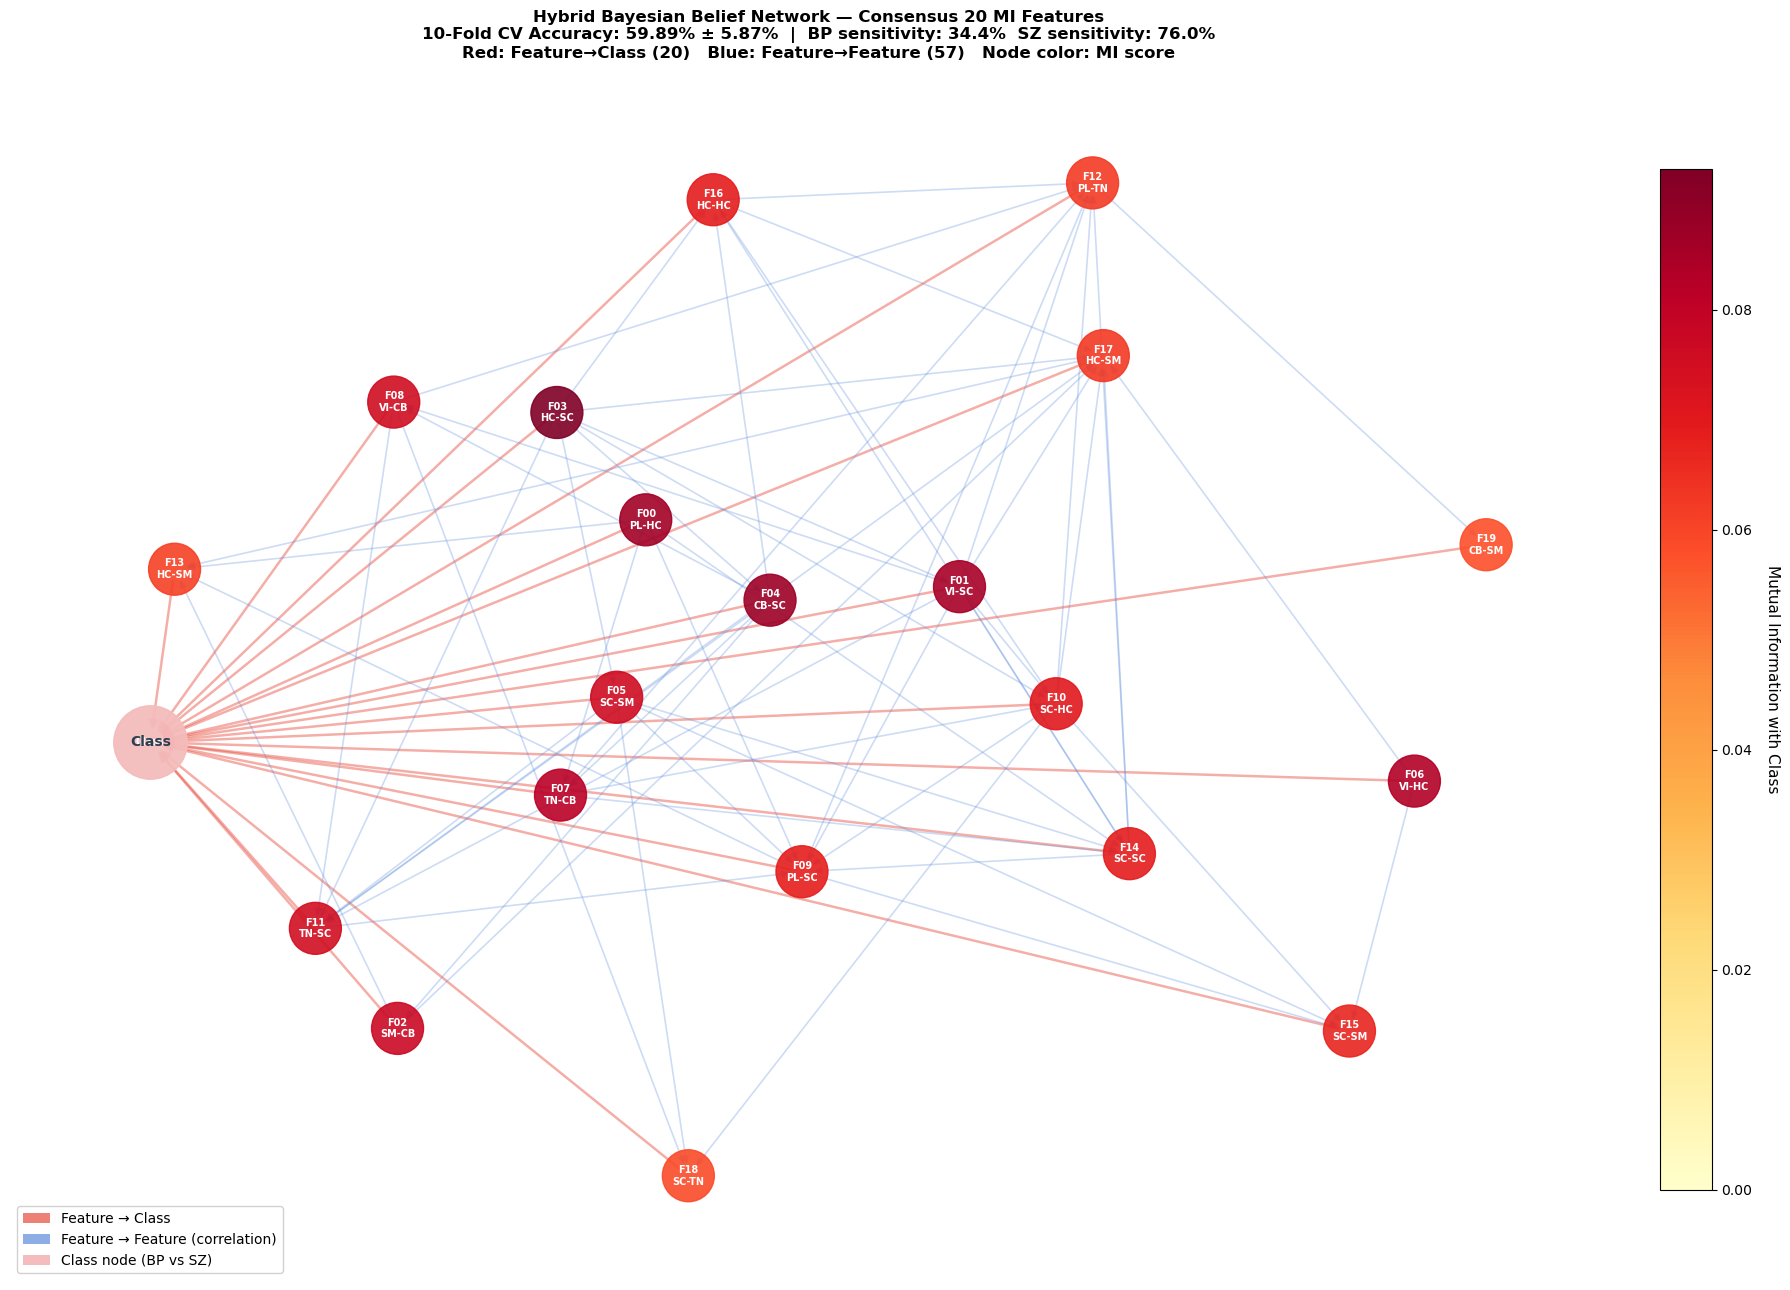

  Saved: bbn_network_domain.png

DONE


In [29]:
"""
DAG BBN: BP vs SZ Classification + Network Visualization
=========================================================
One complete script:
  1. Load Neuromark domain labels
  2. Load training data
  3. Compute consensus 20 MI features (no leakage, inside CV folds)
  4. Run 10-fold CV with manual DAG BBN → accuracy
  5. Visualize BBN network graph (Block 5.5 style + domain labels)

No pgmpy required. Works on Python 3.13.
"""

import os, zlib, re
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import networkx as nx
from collections import Counter
from datetime import datetime
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.feature_selection import mutual_info_classif

# =============================================================================
# CONFIG
# =============================================================================
BASE_DIR        = os.getcwd()
MAT_FILE        = os.path.join(BASE_DIR, 'Neuromark20_to_N22_labels.mat')
BP_DIR          = os.path.expanduser('~/data/data/train/BP')
SZ_DIR          = os.path.expanduser('~/data/data/train/SZ')
N_SELECT        = 20
N_BINS          = 3
ESS             = 10
N_FOLDS         = 10
RANDOM_STATE    = 42
CORR_PERCENTILE = 70

np.random.seed(RANDOM_STATE)

# =============================================================================
# BLOCK 1: Manual BBN classifier
# =============================================================================
class ManualBBN:
    """
    DAG BBN: Diagnosis → each feature.
    P(Diagnosis | F0..F19) ∝ P(Diagnosis) × ∏ P(Fi | Diagnosis)
    BDeu smoothing with equivalent_sample_size=ESS.
    """
    def __init__(self, n_bins=3, ess=10):
        self.n_bins = n_bins
        self.ess = ess

    def fit(self, X, y):
        n_samples, n_features = X.shape
        C, K = 2, self.n_bins
        class_counts = np.bincount(y, minlength=C)
        self.prior = (class_counts + self.ess/C) / (n_samples + self.ess)
        self.cpt = np.zeros((n_features, C, K))
        alpha = self.ess / (K * C)
        for c in range(C):
            X_c = X[y == c]
            for f in range(n_features):
                bc = np.bincount(X_c[:, f], minlength=K)
                self.cpt[f, c, :] = (bc + alpha) / (len(X_c) + alpha * K)
        return self

    def predict(self, X):
        log_prior = np.log(self.prior)
        preds = []
        for i in range(len(X)):
            log_p = log_prior.copy()
            for f in range(X.shape[1]):
                log_p += np.log(self.cpt[f, :, int(X[i, f])])
            log_p -= log_p.max()
            preds.append(np.argmax(np.exp(log_p)))
        return np.array(preds)

# =============================================================================
# BLOCK 2: Load Neuromark labels
# =============================================================================
print("=" * 70)
print("BLOCK 2: Loading Neuromark labels")
print("=" * 70)

def load_neuromark_labels(mat_file):
    with open(mat_file, 'rb') as f:
        raw = f.read()
    positions = [m.start() for m in re.finditer(b'\x78\x9c', raw)]
    decompressed = zlib.decompress(raw[positions[-1]:])
    text = decompressed.decode('utf-16-le', errors='ignore')
    all_labels = re.findall(r'[A-Z]{2}', text)
    domain_labels    = all_labels[:105]
    subdomain_labels = all_labels[105:]
    mat = sio.loadmat(mat_file, squeeze_me=True)
    order = mat['N20_to_N22_order'].astype(int) - 1
    return order, domain_labels, subdomain_labels

order, domain_labels, subdomain_labels = load_neuromark_labels(MAT_FILE)
inv_order = np.argsort(order)
rows_icn, cols_icn = np.triu_indices(105, k=1)

def get_domain_label(feat_idx):
    icn_i = inv_order[rows_icn[feat_idx]]
    icn_j = inv_order[cols_icn[feat_idx]]
    return f"{domain_labels[icn_i]}-{domain_labels[icn_j]}"

print(f"  Domain counts: {Counter(domain_labels)}")

# =============================================================================
# BLOCK 3: Load training data
# =============================================================================
print("\n" + "=" * 70)
print("BLOCK 3: Loading training data")
print("=" * 70)

def load_subjects(folder, label):
    X, y = [], []
    for subj in sorted(d for d in os.listdir(folder) if d.startswith('sub')):
        fnc_file = os.path.join(folder, subj, 'fnc.npy')
        if os.path.exists(fnc_file):
            fnc = np.load(fnc_file).flatten()
            if len(fnc) == 5460:
                X.append(fnc); y.append(label)
    return np.array(X), np.array(y)

X_bp, y_bp = load_subjects(BP_DIR, 0)
X_sz, y_sz = load_subjects(SZ_DIR, 1)
X_all = np.vstack([X_bp, X_sz])
y_all = np.hstack([y_bp, y_sz]).astype(int)
print(f"  BP: {len(X_bp)}, SZ: {len(X_sz)}, Total: {len(X_all)}")

# =============================================================================
# BLOCK 4: 10-Fold CV — consensus MI + BBN accuracy
# =============================================================================
print("\n" + "=" * 70)
print("BLOCK 4: 10-Fold CV (DAG BBN, Diagnosis → 20 MI features)")
print("=" * 70)
print(f"  MI recomputed inside each fold on training data only (no leakage)")
print(f"  Bins: {N_BINS} (quantile) | BDeu ESS: {ESS}")

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

bbn_accs          = []
bbn_cms           = []
fold_selections   = []    # for consensus
overall_start     = datetime.now()

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_all, y_all)):
    fold_start = datetime.now()

    X_fold_train = X_all[train_idx]
    X_fold_test  = X_all[test_idx]
    y_fold_train = y_all[train_idx]
    y_fold_test  = y_all[test_idx]

    # --- MI on training fold only ---
    mi = mutual_info_classif(X_fold_train, y_fold_train, random_state=RANDOM_STATE)
    top_idx = np.argsort(mi)[::-1][:N_SELECT]
    fold_selections.append(top_idx)

    X_sel_train = X_fold_train[:, top_idx]
    X_sel_test  = X_fold_test[:, top_idx]

    # --- Discretize ---
    disc = KBinsDiscretizer(n_bins=N_BINS, encode='ordinal', strategy='quantile')
    X_disc_train = disc.fit_transform(X_sel_train).astype(int)
    X_disc_test  = disc.transform(X_sel_test).astype(int)

    # --- Fit & predict ---
    bbn = ManualBBN(n_bins=N_BINS, ess=ESS)
    bbn.fit(X_disc_train, y_fold_train)
    preds = bbn.predict(X_disc_test)

    acc = accuracy_score(y_fold_test, preds)
    cm  = confusion_matrix(y_fold_test, preds)
    bbn_accs.append(acc)
    bbn_cms.append(cm)

    fold_time = (datetime.now() - fold_start).total_seconds()
    print(f"  Fold {fold_idx+1:2d}: {acc*100:.2f}%  ({fold_time:.1f}s)")

total_time = (datetime.now() - overall_start).total_seconds()
bbn_accs = np.array(bbn_accs)

print(f"\n  Mean:  {bbn_accs.mean()*100:.2f}% ± {bbn_accs.std()*100:.2f}%")
print(f"  Min:   {bbn_accs.min()*100:.2f}% (Fold {np.argmin(bbn_accs)+1})")
print(f"  Max:   {bbn_accs.max()*100:.2f}% (Fold {np.argmax(bbn_accs)+1})")
print(f"  Time:  {total_time:.1f}s")

total_cm = np.sum(bbn_cms, axis=0)
bp_sens = total_cm[0,0] / total_cm[0].sum()
sz_sens = total_cm[1,1] / total_cm[1].sum()
print(f"\n  Confusion matrix (aggregated):")
print(f"            Pred BP  Pred SZ")
print(f"  True BP     {total_cm[0,0]:4d}     {total_cm[0,1]:4d}")
print(f"  True SZ     {total_cm[1,0]:4d}     {total_cm[1,1]:4d}")
print(f"\n  BP sensitivity: {bp_sens*100:.2f}%")
print(f"  SZ sensitivity: {sz_sens*100:.2f}%")

pd.DataFrame({'Fold': range(1, N_FOLDS+1), 'Accuracy': bbn_accs})\
  .to_csv('bbn_dag_results.csv', index=False)
print("\n  Saved: bbn_dag_results.csv")

# =============================================================================
# BLOCK 5: Consensus features (from fold selections)
# =============================================================================
print("\n" + "=" * 70)
print("BLOCK 5: Consensus MI features")
print("=" * 70)

all_selected = np.concatenate(fold_selections)
feat_counts  = Counter(all_selected)
bbn_indices  = np.array([fi for fi, _ in feat_counts.most_common(N_SELECT)])

print(f"\n  Top {N_SELECT} consensus features:")
for i, fi in enumerate(bbn_indices):
    print(f"  F{i:02d}: idx={fi:5d}  folds={feat_counts[fi]}/10  "
          f"domain={get_domain_label(fi)}")

np.save('consensus_20_mi_features.npy', bbn_indices)
print("\n  Saved: consensus_20_mi_features.npy")

# =============================================================================
# BLOCK 6: Build BBN graph for visualization
# =============================================================================
print("\n" + "=" * 70)
print("BLOCK 6: Building BBN graph")
print("=" * 70)

X_bbn       = X_all[:, bbn_indices]
mi_scores   = mutual_info_classif(X_bbn, y_all, random_state=RANDOM_STATE)
corr_matrix = np.corrcoef(X_bbn.T)
domain_feat = [get_domain_label(fi) for fi in bbn_indices]
feat_nodes  = [f"F{i:02d}\n{domain_feat[i]}" for i in range(N_SELECT)]

G = nx.DiGraph()
G.add_nodes_from(feat_nodes)
G.add_node('Class')

for fn in feat_nodes:
    G.add_edge(fn, 'Class')

abs_corr = np.abs(corr_matrix)
np.fill_diagonal(abs_corr, 0)
threshold = np.percentile(
    abs_corr[np.triu_indices_from(abs_corr, k=1)], CORR_PERCENTILE
)

def would_create_cycle(G, src, tgt):
    try:
        nx.shortest_path(G, tgt, src)
        return True
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        return False

for i in range(N_SELECT):
    for j in range(i+1, N_SELECT):
        if abs_corr[i, j] > threshold:
            src = feat_nodes[i] if mi_scores[i] > mi_scores[j] else feat_nodes[j]
            tgt = feat_nodes[j] if mi_scores[i] > mi_scores[j] else feat_nodes[i]
            if not would_create_cycle(G, src, tgt):
                G.add_edge(src, tgt)

edges_to_class = [(u, v) for u, v in G.edges() if v == 'Class']
edges_ff       = [(u, v) for u, v in G.edges() if v != 'Class']
print(f"  Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")
print(f"  Feature→Class: {len(edges_to_class)} | Feature→Feature: {len(edges_ff)}")

# =============================================================================
# BLOCK 7: Plot network + accuracy
# =============================================================================
print("\n" + "=" * 70)
print("BLOCK 7: Plotting BBN network")
print("=" * 70)

pos         = nx.spring_layout(G, k=3, iterations=100, seed=RANDOM_STATE)
norm        = mcolors.Normalize(vmin=0, vmax=mi_scores.max())
cmap        = plt.cm.YlOrRd
feat_colors = [cmap(norm(mi_scores[i])) for i in range(N_SELECT)]

fig, ax = plt.subplots(figsize=(18, 13))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

nx.draw_networkx_nodes(G, pos, nodelist=feat_nodes,
                       node_color=feat_colors, node_size=1400,
                       alpha=0.9, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=['Class'],
                       node_color='#F4BCBC', node_size=2800,
                       alpha=0.95, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=edges_to_class,
                       width=1.8, alpha=0.45, edge_color='#E74C3C',
                       arrows=True, arrowsize=14, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=edges_ff,
                       width=1.2, alpha=0.30, edge_color='#5B8CDB',
                       arrows=True, arrowsize=11, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7,
                        font_weight='bold', font_color='white', ax=ax)
nx.draw_networkx_labels(G, pos, labels={'Class': 'Class'},
                        font_size=10, font_weight='bold',
                        font_color='#2C3E50', ax=ax)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Mutual Information with Class',
               rotation=270, labelpad=20, fontsize=11)

legend_elements = [
    mpatches.Patch(facecolor='#E74C3C', alpha=0.7,
                   label='Feature → Class'),
    mpatches.Patch(facecolor='#5B8CDB', alpha=0.7,
                   label='Feature → Feature (correlation)'),
    mpatches.Patch(facecolor='#F4BCBC',
                   label='Class node (BP vs SZ)'),
]
ax.legend(handles=legend_elements, loc='lower left',
          fontsize=10, framealpha=0.9)

ax.set_title(
    f'Hybrid Bayesian Belief Network — Consensus 20 MI Features\n'
    f'10-Fold CV Accuracy: {bbn_accs.mean()*100:.2f}% ± {bbn_accs.std()*100:.2f}%  |  '
    f'BP sensitivity: {bp_sens*100:.1f}%  SZ sensitivity: {sz_sens*100:.1f}%\n'
    f'Red: Feature→Class ({len(edges_to_class)})   '
    f'Blue: Feature→Feature ({len(edges_ff)})   '
    f'Node color: MI score',
    fontsize=12, fontweight='bold', pad=15
)

ax.axis('off')
plt.tight_layout()
plt.savefig('bbn_network_domain.png', dpi=300, bbox_inches='tight')
plt.show()
print("  Saved: bbn_network_domain.png")

print("\n" + "=" * 70)
print("DONE")
print("=" * 70)

BLOCK 1: Loading Neuromark labels
  Domain counts: Counter({'HC': 22, 'SC': 18, 'TN': 15, 'SM': 14, 'CB': 13, 'VI': 12, 'PL': 11})

BLOCK 2: Loading training data
  BP: 183, SZ: 288, Total: 471

BLOCK 3: 10-Fold CV (GaussianNB BBN, Diagnosis → 20 MI features)
  MI recomputed inside each fold on training data only (no leakage)
  Features: continuous (no discretization)


/opt/anaconda3/lib/python3.13/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


  Fold  1: 52.08%  (2.8s)
  Fold  2: 63.83%  (2.8s)
  Fold  3: 61.70%  (2.8s)
  Fold  4: 65.96%  (2.8s)
  Fold  5: 55.32%  (2.9s)
  Fold  6: 55.32%  (3.1s)
  Fold  7: 57.45%  (2.9s)
  Fold  8: 57.45%  (2.9s)
  Fold  9: 48.94%  (2.9s)
  Fold 10: 55.32%  (2.9s)

  Mean:  57.34% ± 4.96%
  Min:   48.94% (Fold 9)
  Max:   65.96% (Fold 4)
  Time:  28.8s

  Aggregated confusion matrix:
            Pred BP  Pred SZ
  True BP       61      122
  True SZ       79      209

  BP sensitivity: 33.33%
  SZ sensitivity: 72.57%

  Saved: bbn_dag_results.csv

BLOCK 4: Consensus MI features

  Top 20 consensus features:
  F00: idx= 5111  folds=10/10  domain=PL-HC
  F01: idx= 1555  folds=8/10  domain=VI-SC
  F02: idx= 2329  folds=8/10  domain=SM-CB
  F03: idx= 4222  folds=8/10  domain=HC-SC
  F04: idx=  444  folds=7/10  domain=CB-SC
  F05: idx= 3243  folds=7/10  domain=SC-SM
  F06: idx= 1990  folds=6/10  domain=VI-HC
  F07: idx=  533  folds=5/10  domain=TN-CB
  F08: idx= 1732  folds=5/10  domain=VI-CB
  

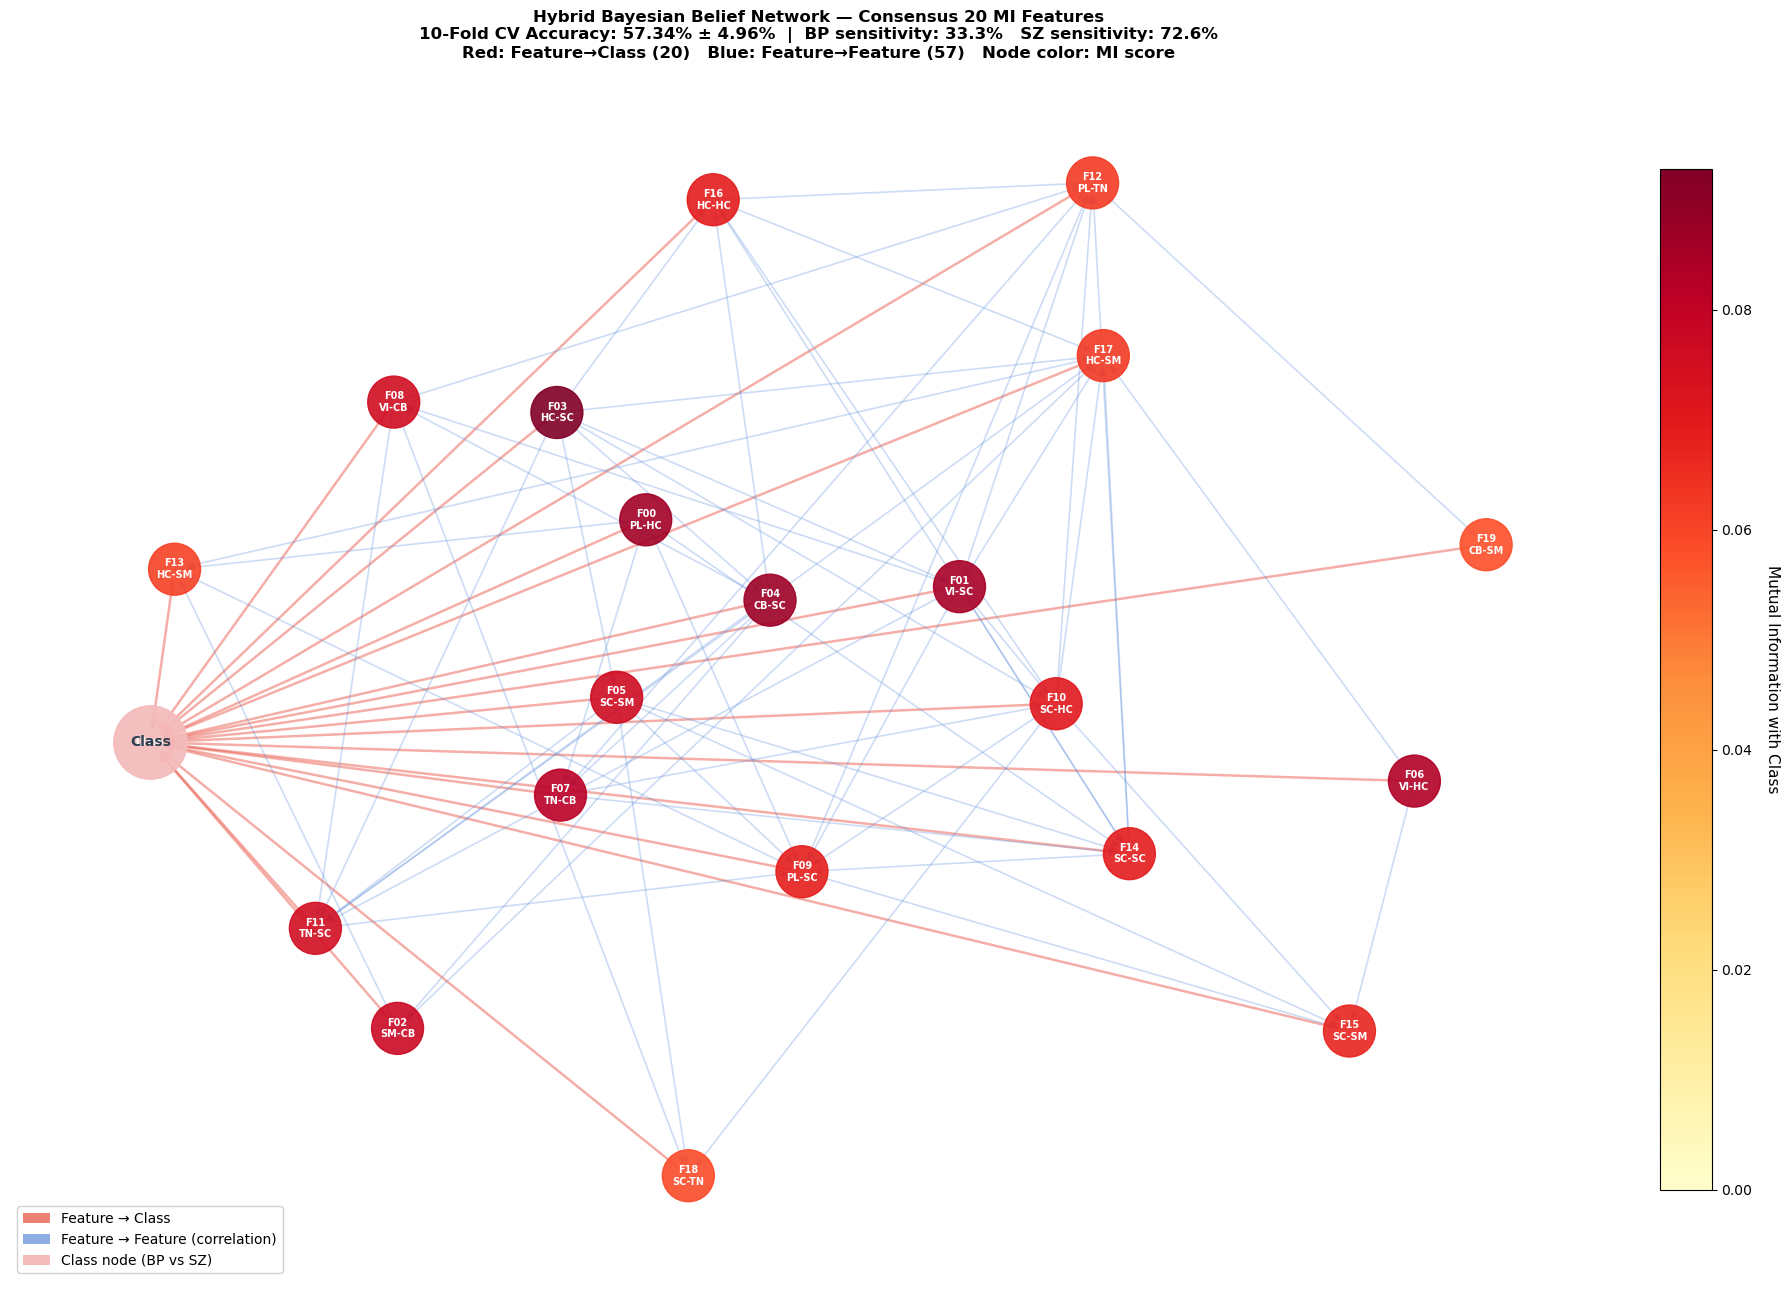

  Saved: bbn_network_domain.png

DONE


In [30]:
"""
DAG BBN: BP vs SZ Classification + Network Visualization
=========================================================
One complete script:
  1. Load Neuromark domain labels
  2. Load training data
  3. 10-fold CV with GaussianNB BBN (no leakage, MI inside each fold)
  4. Derive consensus 20 features from fold selections
  5. Visualize BBN network (Block 5.5 style + domain labels + accuracy)

DAG structure:  Diagnosis -> Feature_1 ... Feature_20
CPDs:           Gaussian (mean/variance per class per feature)
No pgmpy, no discretization. Works on Python 3.13.
"""

import os, zlib, re
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import networkx as nx
from collections import Counter
from datetime import datetime
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_selection import mutual_info_classif
from sklearn.naive_bayes import GaussianNB

# =============================================================================
# CONFIG
# =============================================================================
BASE_DIR        = os.getcwd()
MAT_FILE        = os.path.join(BASE_DIR, 'Neuromark20_to_N22_labels.mat')
BP_DIR          = os.path.expanduser('~/data/data/train/BP')
SZ_DIR          = os.path.expanduser('~/data/data/train/SZ')
N_SELECT        = 20
N_FOLDS         = 10
RANDOM_STATE    = 42
CORR_PERCENTILE = 70   # top 30% correlations become feature-feature edges

np.random.seed(RANDOM_STATE)

# =============================================================================
# BLOCK 1: Load Neuromark labels
# =============================================================================
print("=" * 70)
print("BLOCK 1: Loading Neuromark labels")
print("=" * 70)

def load_neuromark_labels(mat_file):
    with open(mat_file, 'rb') as f:
        raw = f.read()
    positions = [m.start() for m in re.finditer(b'\x78\x9c', raw)]
    decompressed = zlib.decompress(raw[positions[-1]:])
    text = decompressed.decode('utf-16-le', errors='ignore')
    all_labels = re.findall(r'[A-Z]{2}', text)
    domain_labels    = all_labels[:105]
    subdomain_labels = all_labels[105:]
    mat = sio.loadmat(mat_file, squeeze_me=True)
    order = mat['N20_to_N22_order'].astype(int) - 1
    return order, domain_labels, subdomain_labels

order, domain_labels, subdomain_labels = load_neuromark_labels(MAT_FILE)
inv_order = np.argsort(order)
rows_icn, cols_icn = np.triu_indices(105, k=1)

def get_domain_label(feat_idx):
    icn_i = inv_order[rows_icn[feat_idx]]
    icn_j = inv_order[cols_icn[feat_idx]]
    return f"{domain_labels[icn_i]}-{domain_labels[icn_j]}"

print(f"  Domain counts: {Counter(domain_labels)}")

# =============================================================================
# BLOCK 2: Load training data
# =============================================================================
print("\n" + "=" * 70)
print("BLOCK 2: Loading training data")
print("=" * 70)

def load_subjects(folder, label):
    X, y = [], []
    for subj in sorted(d for d in os.listdir(folder) if d.startswith('sub')):
        fnc_file = os.path.join(folder, subj, 'fnc.npy')
        if os.path.exists(fnc_file):
            fnc = np.load(fnc_file).flatten()
            if len(fnc) == 5460:
                X.append(fnc); y.append(label)
    return np.array(X), np.array(y)

X_bp, y_bp = load_subjects(BP_DIR, 0)
X_sz, y_sz = load_subjects(SZ_DIR, 1)
X_all = np.vstack([X_bp, X_sz])
y_all = np.hstack([y_bp, y_sz]).astype(int)
print(f"  BP: {len(X_bp)}, SZ: {len(X_sz)}, Total: {len(X_all)}")

# =============================================================================
# BLOCK 3: 10-Fold CV — GaussianNB BBN (no leakage)
# MI computed on training fold only.
# GaussianNB models P(Fi | Diagnosis) as Gaussian — same as BBN with
# Gaussian CPDs on DAG: Diagnosis → F0, F1, ... F19
# =============================================================================
print("\n" + "=" * 70)
print("BLOCK 3: 10-Fold CV (GaussianNB BBN, Diagnosis → 20 MI features)")
print("=" * 70)
print(f"  MI recomputed inside each fold on training data only (no leakage)")
print(f"  Features: continuous (no discretization)")

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

bbn_accs        = []
bbn_cms         = []
fold_selections = []
overall_start   = datetime.now()

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_all, y_all)):
    fold_start = datetime.now()

    X_fold_train = X_all[train_idx]
    X_fold_test  = X_all[test_idx]
    y_fold_train = y_all[train_idx]
    y_fold_test  = y_all[test_idx]

    # --- MI on training fold only ---
    mi = mutual_info_classif(
        X_fold_train, y_fold_train, random_state=RANDOM_STATE
    )
    top_idx = np.argsort(mi)[::-1][:N_SELECT]
    fold_selections.append(top_idx)

    X_sel_train = X_fold_train[:, top_idx]
    X_sel_test  = X_fold_test[:, top_idx]

    # --- GaussianNB: models P(Fi | Diagnosis) as Gaussian per class ---
    gnb = GaussianNB()
    gnb.fit(X_sel_train, y_fold_train)
    preds = gnb.predict(X_sel_test)

    acc = accuracy_score(y_fold_test, preds)
    cm  = confusion_matrix(y_fold_test, preds)
    bbn_accs.append(acc)
    bbn_cms.append(cm)

    fold_time = (datetime.now() - fold_start).total_seconds()
    print(f"  Fold {fold_idx+1:2d}: {acc*100:.2f}%  ({fold_time:.1f}s)")

total_time = (datetime.now() - overall_start).total_seconds()
bbn_accs   = np.array(bbn_accs)

print(f"\n  Mean:  {bbn_accs.mean()*100:.2f}% ± {bbn_accs.std()*100:.2f}%")
print(f"  Min:   {bbn_accs.min()*100:.2f}% (Fold {np.argmin(bbn_accs)+1})")
print(f"  Max:   {bbn_accs.max()*100:.2f}% (Fold {np.argmax(bbn_accs)+1})")
print(f"  Time:  {total_time:.1f}s")

total_cm = np.sum(bbn_cms, axis=0)
bp_sens  = total_cm[0, 0] / total_cm[0].sum()
sz_sens  = total_cm[1, 1] / total_cm[1].sum()
print(f"\n  Aggregated confusion matrix:")
print(f"            Pred BP  Pred SZ")
print(f"  True BP     {total_cm[0,0]:4d}     {total_cm[0,1]:4d}")
print(f"  True SZ     {total_cm[1,0]:4d}     {total_cm[1,1]:4d}")
print(f"\n  BP sensitivity: {bp_sens*100:.2f}%")
print(f"  SZ sensitivity: {sz_sens*100:.2f}%")

pd.DataFrame({'Fold': range(1, N_FOLDS+1), 'Accuracy': bbn_accs})\
  .to_csv('bbn_dag_results.csv', index=False)
print("\n  Saved: bbn_dag_results.csv")

# =============================================================================
# BLOCK 4: Consensus features from fold selections
# =============================================================================
print("\n" + "=" * 70)
print("BLOCK 4: Consensus MI features")
print("=" * 70)

all_selected = np.concatenate(fold_selections)
feat_counts  = Counter(all_selected)
bbn_indices  = np.array([fi for fi, _ in feat_counts.most_common(N_SELECT)])

print(f"\n  Top {N_SELECT} consensus features:")
for i, fi in enumerate(bbn_indices):
    print(f"  F{i:02d}: idx={fi:5d}  folds={feat_counts[fi]}/10  "
          f"domain={get_domain_label(fi)}")

np.save('consensus_20_mi_features.npy', bbn_indices)
print("\n  Saved: consensus_20_mi_features.npy")

# =============================================================================
# BLOCK 5: Build BBN graph for visualization
# =============================================================================
print("\n" + "=" * 70)
print("BLOCK 5: Building BBN graph")
print("=" * 70)

X_bbn       = X_all[:, bbn_indices]
mi_scores   = mutual_info_classif(X_bbn, y_all, random_state=RANDOM_STATE)
corr_matrix = np.corrcoef(X_bbn.T)
domain_feat = [get_domain_label(fi) for fi in bbn_indices]
feat_nodes  = [f"F{i:02d}\n{domain_feat[i]}" for i in range(N_SELECT)]

G = nx.DiGraph()
G.add_nodes_from(feat_nodes)
G.add_node('Class')

for fn in feat_nodes:
    G.add_edge(fn, 'Class')

abs_corr = np.abs(corr_matrix)
np.fill_diagonal(abs_corr, 0)
threshold = np.percentile(
    abs_corr[np.triu_indices_from(abs_corr, k=1)], CORR_PERCENTILE
)

def would_create_cycle(G, src, tgt):
    try:
        nx.shortest_path(G, tgt, src)
        return True
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        return False

for i in range(N_SELECT):
    for j in range(i+1, N_SELECT):
        if abs_corr[i, j] > threshold:
            src = feat_nodes[i] if mi_scores[i] > mi_scores[j] else feat_nodes[j]
            tgt = feat_nodes[j] if mi_scores[i] > mi_scores[j] else feat_nodes[i]
            if not would_create_cycle(G, src, tgt):
                G.add_edge(src, tgt)

edges_to_class = [(u, v) for u, v in G.edges() if v == 'Class']
edges_ff       = [(u, v) for u, v in G.edges() if v != 'Class']
print(f"  Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")
print(f"  Feature→Class: {len(edges_to_class)} | Feature→Feature: {len(edges_ff)}")

# =============================================================================
# BLOCK 6: Plot network with accuracy in title
# =============================================================================
print("\n" + "=" * 70)
print("BLOCK 6: Plotting BBN network")
print("=" * 70)

pos         = nx.spring_layout(G, k=3, iterations=100, seed=RANDOM_STATE)
norm        = mcolors.Normalize(vmin=0, vmax=mi_scores.max())
cmap        = plt.cm.YlOrRd
feat_colors = [cmap(norm(mi_scores[i])) for i in range(N_SELECT)]

fig, ax = plt.subplots(figsize=(18, 13))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

nx.draw_networkx_nodes(G, pos, nodelist=feat_nodes,
                       node_color=feat_colors, node_size=1400,
                       alpha=0.9, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=['Class'],
                       node_color='#F4BCBC', node_size=2800,
                       alpha=0.95, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=edges_to_class,
                       width=1.8, alpha=0.45, edge_color='#E74C3C',
                       arrows=True, arrowsize=14, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=edges_ff,
                       width=1.2, alpha=0.30, edge_color='#5B8CDB',
                       arrows=True, arrowsize=11, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7,
                        font_weight='bold', font_color='white', ax=ax)
nx.draw_networkx_labels(G, pos, labels={'Class': 'Class'},
                        font_size=10, font_weight='bold',
                        font_color='#2C3E50', ax=ax)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Mutual Information with Class',
               rotation=270, labelpad=20, fontsize=11)

legend_elements = [
    mpatches.Patch(facecolor='#E74C3C', alpha=0.7,
                   label='Feature → Class'),
    mpatches.Patch(facecolor='#5B8CDB', alpha=0.7,
                   label='Feature → Feature (correlation)'),
    mpatches.Patch(facecolor='#F4BCBC',
                   label='Class node (BP vs SZ)'),
]
ax.legend(handles=legend_elements, loc='lower left',
          fontsize=10, framealpha=0.9)

ax.set_title(
    f'Hybrid Bayesian Belief Network — Consensus 20 MI Features\n'
    f'10-Fold CV Accuracy: {bbn_accs.mean()*100:.2f}% ± {bbn_accs.std()*100:.2f}%  |  '
    f'BP sensitivity: {bp_sens*100:.1f}%   SZ sensitivity: {sz_sens*100:.1f}%\n'
    f'Red: Feature→Class ({len(edges_to_class)})   '
    f'Blue: Feature→Feature ({len(edges_ff)})   '
    f'Node color: MI score',
    fontsize=12, fontweight='bold', pad=15
)

ax.axis('off')
plt.tight_layout()
plt.savefig('bbn_network_domain.png', dpi=300, bbox_inches='tight')
plt.show()
print("  Saved: bbn_network_domain.png")

print("\n" + "=" * 70)
print("DONE")
print("=" * 70)